# Assignment 3: Score Based Generative Modeling Through Stochastic Differential Equations

In this assignment, you will be implementing architectures seen in the paper Scored Based Generative Modeling Through Stochastic Differential Equations, which we saw in the tutorials connects between the two methods you have already implemented. Due to this already being the third assignment, there will be less guidance throughout the exercise and you will have more of a free hand. Remember to turn off machines when you're not using them, and to frequently save checkpoints of your models!

The free hand means that documentation is important. We expect non-trivial functions to be documented. Additionally, we expect (brief) explanations in the notebook of how you chose to implement each part of the assignment. Good luck!

## Submission Guidelines

- If it is more comfortable, you may submit either a python project with several files which define functions or a single python notebook that implements everything. The python notebook should include outputs, even if they are not the same outputs as the ones you submit in the zip.
- If you choose to submit using a python project, you must also submit a notebook that runs all relevant functions and generates all outputs (they don't need to be the same as the ones that are in the visualization zip, but we should be able to see that all functions run correctly). There should be two zips in this case: one containing all code files (including the notebook that replicates the outputs) and another containing the visualizations as done before.
- You may name the zip files as you wish, as long as your ID is in the name.
- All other requirements are based on the requirements in the syllabus.
- Reminder: You can play with the functions as much as you want to, and don't need to implement functions using the same parameters / names as what we provide. All changes that you make should be documented and should still do all the things you're required to do.

In [109]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.nn.init as init
from torch.distributions import Normal
import numpy as np
from torchvision.datasets import MNIST
from torchvision import transforms
from torch.utils.data import DataLoader
from torchvision.utils import save_image
from tqdm import tqdm
import os
import matplotlib.pyplot as plt
import seaborn as sns
import math
import einops
from einops import rearrange 

## Part 1: Visualizing SDEs Using Simulations

In this part, we will recreate part of Figure 2 in https://arxiv.org/pdf/2011.13456 using Euler's method for sampling from SDEs. In particular, we will be recreating the Variance Preserving SDE (DDPM's continuous form):

$$
d\textbf{x}_t = -\frac{1}{2}\beta_t \textbf{x}_t dt + \sqrt{\beta_t} d\textbf{w}_t
$$

Note that in the paper, Figure 2 is of the ALD based SDE, so it looks different than what you will be creating. Throughout this part of the assignment, we will be working with $\beta_0 = 0.1, \beta_1 = 20$, $\beta(t) = (\beta_1 - \beta_0)t + \beta_0$. $\mathbf{x}_0$ follows a mixture of Gaussians distribution, with probability 0.5 of being centered around -3 and 0.5 of being centered around 3, with standard deviation 0.5.

This part can be entirely run on your PC, without needing the VM or CUDA. We strongly recommend to run this part of the assignment locally. 

1. For $\textbf{x} \in \mathbb{R}$, formulate the ground truth distribution $p_t(\textbf{x}_t | \textbf{x}_0)$ and the function $\nabla_{\textbf{x}_t} \log p_t(\textbf{x}_t | \textbf{x}_0)$. Note $\Sigma_0 = 0$.
2. Train a simple model using the loss from tutorials 5/6 to approximate the marginal score: $\nabla_{\textbf{x}_t}\log p_t(\textbf{x}_t)$, for the above SDE.
3. Sample 100,000 values for $\textbf{x}_0$ following a mixture of Gaussians, probability 0.5 of being centered around -3 and 0.5 being centered around 3, with standard deviation 0.5. Advance them according to the SDE provided in DDPM, using Euler's method with `T=1000` and step size `1e-3`. What is the distribution we reached?
4. For 10,000 random starting points, advance them according to the probability flow ODE, using the score you learned. Note that despite the fact that you need the score to do this, *you are still advancing the points according to the forward process*! 
5. Now, reverse the process by sampling 10,000 samples from the prior distribution and taking reverse steps according to the reverse SDE using the score. To sample using Euler in the reverse process, see equation 46 in the paper linked above (in Appendix E, $\mathbf{f}\equiv \mu, \mathbf{G}\equiv \sigma$). Display the trajectory of 2 random starting points using the reverse SDE.
6. Bonus (2 points): Sample 10,000 points according to the reverse probability flow ODE and display the trajectory of two random starting points.

Display the histogram of $\mathbf{x}_t$ as a function of time using a heatmap on the $y$ axis. You can use meshgrids and `matplotlib`'s pcolormesh to display the histogram as shown below. There should be 3/4 total histograms:

1. Histogram of Euler discretization of forward SDE (100,000 starting points).
2. Histogram of Euler discretization of probability flow ODE (10,000 starting points). It's ok if the histogram isn't as nice as the SDE histogram, but points will still be deducted if it's very different in general behavior.
3. Histogram of Euler discretization of reverse SDE (10,000 starting points). It's ok if it isn't exactly the reverse of the forward SDE, but points will still be removed if there are mistakes in the code.
4. (Bonus) Histogram of Euler discretization of reverse probability flow ODE (10,000 starting points).

Expected outputs for first histogram:

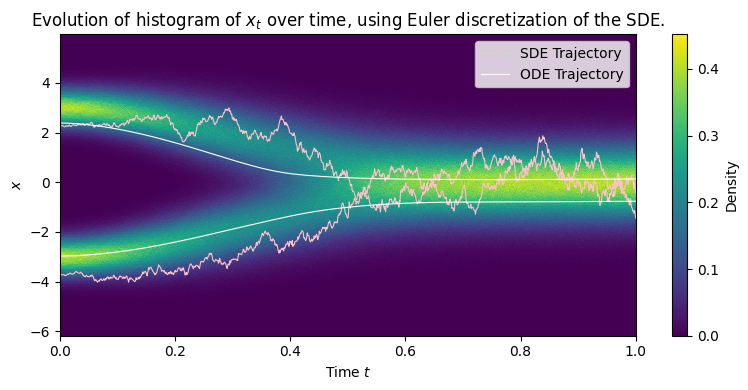

### Section 1

As we have seen in the TA6, we can derive the paramters of the distribution of $\hat{x_t} | \hat{x_0}$ by applying the extended version of the Fokker Planck equation. We get the following covariance matrix and mean respectively:

$$
\Sigma_t \;=\; I \;+\; e^{\int_{0}^{t} -\beta(s)\,ds}\,(\Sigma_0 - I)
$$

$$
\mu_t \;=\; \hat{x}(0)\,e^{-\frac12\int_{0}^{t} \beta(s)\,ds}
$$

Now, assuming $\Sigma_0 = 0$ and $x_t \in \mathbb{R}$, we get: $\Sigma_t \;=\; 1 \;-\; e^{\int_{0}^{1} -\beta(s)\,ds}$. And in total we have the following distribution of $x_t | x_0$ :

$$
x_t \mid x_0 \;\sim\;
\mathcal{N}\!\bigl(\,\mu_t,\;\sigma_t^{2}\bigr)
$$

     
Where
$$
\mu_t \;=\; x(0)\,e^{-\tfrac12 \int_{0}^{t} \beta(s)\,ds}, 
\qquad
\sigma_t^{2} \;=\; 1 \;-\; e^{-\!\int_{0}^{t} \beta(s)\,ds}
$$

Now, we will solve the integral by plugging in $\beta_0 = 0.1, \beta_1 = 20$, $\beta(t) = (\beta_1 - \beta_0)t + \beta_0$:

$$\int_{0}^{t}\!\beta_s ds = \int_{0}^{t}\!\bigl[(\beta_{1}-\beta_{0})\,s+\beta_{0}\bigr]\,ds \;=\; \tfrac12(\beta_{1}-\beta_{0})\,t^{2} + \beta_{0}\,t = 0.1\,t+9.95\,t^{2} $$

$$
\implies \mu_t
   = x_0\,\exp\!\Bigl(-\tfrac12\bigl[0.1\,t+9.95\,t^{2}\bigr]\Bigr)
   = \boxed{x_0\,\exp\!\bigl(-(0.05\,t+4.975\,t^{2})\bigr)}
$$
$$
\sigma_t^{2}
   = \boxed{1-\exp\!\bigl(-(0.1\,t+9.95\,t^{2})\bigr)} 
$$



From here, let's formulate the PDF and the score of the distribution:

$$
p_t(x_t \mid x_0)
 \;=\;
 \frac{1}{\sqrt{2\pi\,\sigma_t^{2}}}\,
 \exp\!\Bigl(-\,\frac{(x_t-\mu_t)^{2}}{2\,\sigma_t^{2}}\Bigr)
$$

---


$$
\nabla_{x_t}\,\log p_t(x_t \mid x_0)
 \;=\;
 \frac{\partial}{\partial x_t}
 \Bigl[
   -\tfrac12\log(2\pi\sigma_t^{2})
   -\frac{(x_t-\mu_t)^{2}}{2\,\sigma_t^{2}}
 \Bigr]
 \;=\;
 \frac{\mu_t - x_t}{\sigma_t^{2}}
$$

### Section 2

Let's define a simple 3-layer MLP and train it to predict the marginal score $\nabla_{x_t} \log p_t(x_t)$ 

In [113]:
# simple MLP
class ScoreNetwork(nn.Module):
    def __init__(self, hidden_size, input_size=2, output_size=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features=input_size, out_features=hidden_size),
            nn.ReLU(),
            nn.Linear(in_features=hidden_size, out_features=hidden_size),
            nn.ReLU(),
            nn.Linear(in_features=hidden_size, out_features=output_size)
        )

    def forward(self, x):
        out = self.net(x)
        return out

In [114]:
def unified_loss(x0, model):
    device = x0.device
    dtype  = x0.dtype

    # to avoid 0's in the variance
    t = torch.clamp(torch.rand(x0.size(0), 1, device=device, dtype=dtype) + 1e-150, 0, 1)   

    # integral and all of its compositions as in Section A
    exp_term = torch.exp((-0.1*t) - (9.95*(t**2)))     
    sqrt_ab = torch.sqrt(exp_term)                      
    sqrt_one_m = torch.sqrt(1.0 - exp_term)            

    eps = torch.randn_like(x0)                     
    x_t = sqrt_ab * x0 + sqrt_one_m * eps    # mu_t + sigma_t * noise               

    # preparing input for the model
    inputs = torch.cat([x_t, t], dim=1)        
    output = model(inputs)                          

    # unified loss - learning the score
    loss = torch.mean(((output * sqrt_one_m) + eps) ** 2)
    return loss
    
def train(model, x0, optim, device, num_epochs=1000):
    
    loss_history = []
    bar = tqdm(range(num_epochs))
    x0 = x0.to(device)

    # diffusing the dataset and computing the loss on the entire set for each epoch
    for epoch in bar:
        optim.zero_grad()
        loss = unified_loss(x0, model)
        if (epoch+1)%50==0:
            print(f"Epoch: {epoch+1}, Loss: {loss}")
        loss_history.append(loss.item())
        loss.backward()
        optim.step()
        
    return loss_history   

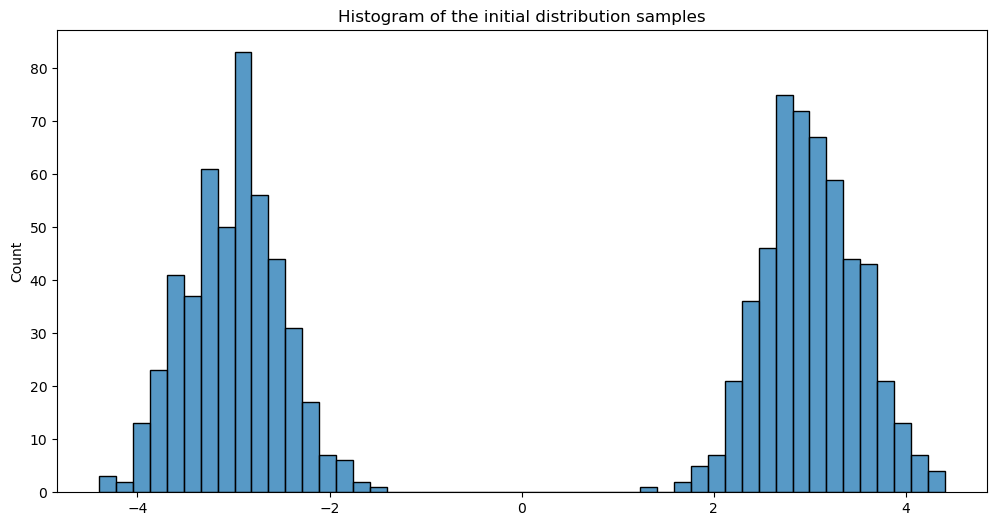

In [115]:
# sampling 10000 points from the initial distribution
data_distribution = torch.distributions.mixture_same_family.MixtureSameFamily(
    torch.distributions.Categorical(torch.tensor([1, 1])),
    torch.distributions.Normal(torch.tensor([-3., 3.]), torch.tensor([0.5, 0.5]))
)

x0 = data_distribution.sample(torch.Size([1000, 1]))
plt.figure(figsize=(12,6))
sns.histplot(x0[:, 0], bins=50)
plt.title('Histogram of the initial distribution samples')
plt.show()

In [116]:
# training the simple score model
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = ScoreNetwork(hidden_size=256).to(device)
optim = torch.optim.Adam(model.parameters(), lr=1e-3)

loss_steps = train(model, x0, optim, device)

 12%|█▏        | 121/1000 [00:00<00:02, 413.61it/s]

Epoch: 50, Loss: 0.37912729382514954
Epoch: 100, Loss: 0.3245203197002411


 22%|██▏       | 223/1000 [00:00<00:01, 470.71it/s]

Epoch: 150, Loss: 0.3704370856285095
Epoch: 200, Loss: 0.2830941081047058
Epoch: 250, Loss: 0.28169965744018555


 38%|███▊      | 377/1000 [00:00<00:01, 496.98it/s]

...

Epoch: 600, Loss: 0.32665321230888367
Epoch: 650, Loss: 0.31144478917121887
Epoch: 700, Loss: 0.2807975113391876


 84%|████████▎ | 837/1000 [00:01<00:00, 507.33it/s]

Epoch: 750, Loss: 0.3163028061389923
Epoch: 800, Loss: 0.28257685899734497
Epoch: 850, Loss: 0.3425842225551605


100%|██████████| 1000/1000 [00:02<00:00, 490.59it/s]

Epoch: 900, Loss: 0.27621322870254517
Epoch: 950, Loss: 0.3016289174556732
Epoch: 1000, Loss: 0.31594139337539673


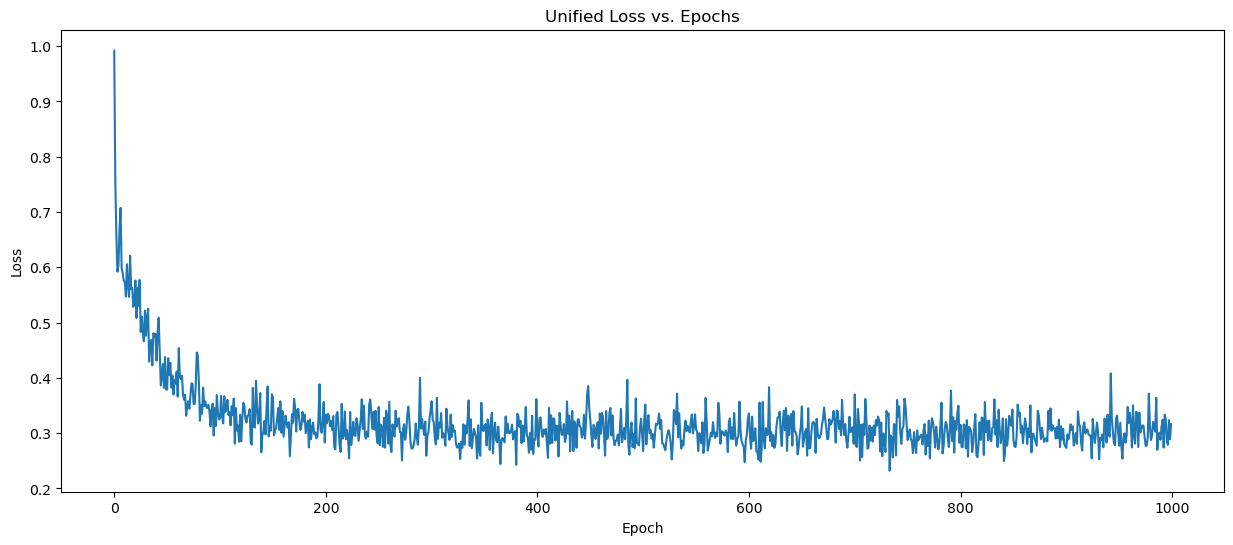

In [117]:
# plotting the loss
plt.figure(figsize=(15,6))
plt.plot(range(len(loss_steps)), loss_steps)
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.title('Unified Loss vs. Epochs')
plt.show()

### Section 3

In [118]:
N = 100_000
beta0 = 0.1
beta1 = 20.0
dt = 1e-3  # step size
T  = 1000  # number of steps

def diffuse(N, T, dt):
    # sample N samples from the initial distribution
    x0 = data_distribution.sample(torch.Size([N, 1]))
    x = x0.clone()
    
    # to store the trajectory
    traj = torch.empty((T+1, *tuple(x.shape)))
    traj[0] = x0.clone()
    
    # euler's method for forward SDE
    t = 0.0
    for i in range(T):
        beta_t = beta0 + (beta1 - beta0) * t
        x += (-0.5 * beta_t * x * dt) + (np.sqrt(beta_t * dt) * torch.randn_like(x))
        t += dt
        traj[i+1] = x.clone()
    return traj

traj = diffuse(N, T, dt)

print(f"Empirical Mean of the diffused samples: {traj[-1].mean().item()}")
print(f"Empirical Variance of the diffused samples: {traj[-1].var().item()}")

Empirical Mean of the diffused samples: -0.0011032420443370938
Empirical Variance of the diffused samples: 0.9997155070304871


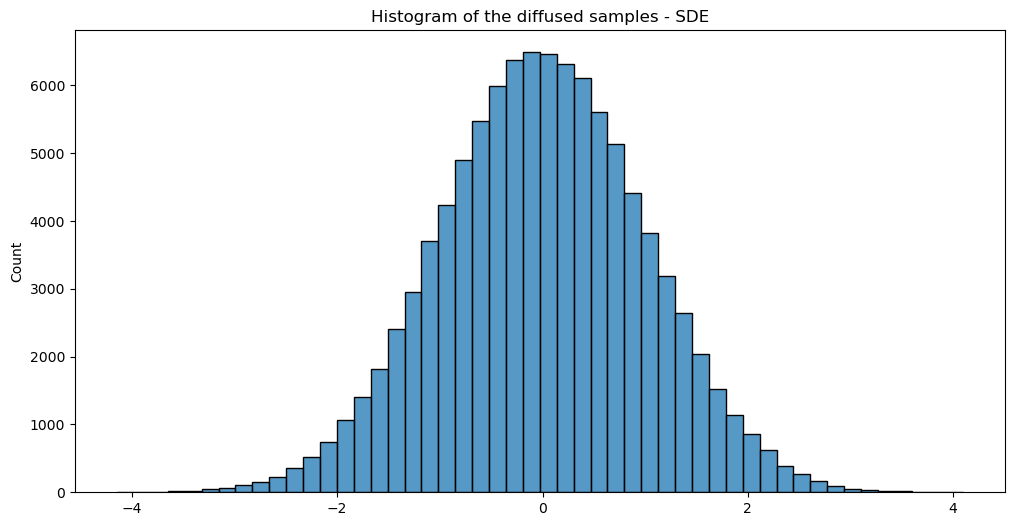

In [119]:
# plot the resulting samples
plt.figure(figsize=(12,6))
sns.histplot(traj[-1][:, 0], bins=50)
plt.title('Histogram of the diffused samples - SDE')
plt.show()

We see that diffusing the samples according to the SDE given by DDPM with the given amount of steps and step size, achieves approximately Normal distribution with mean 0 and variance 1 (white noise).

Now, I will plot the heatmap histogram that evolves with time. On top of what was asked in the assignment. I will kill two bords with one stone and plot the evolution of two arbitrary points on the density histogram that evolves with time.

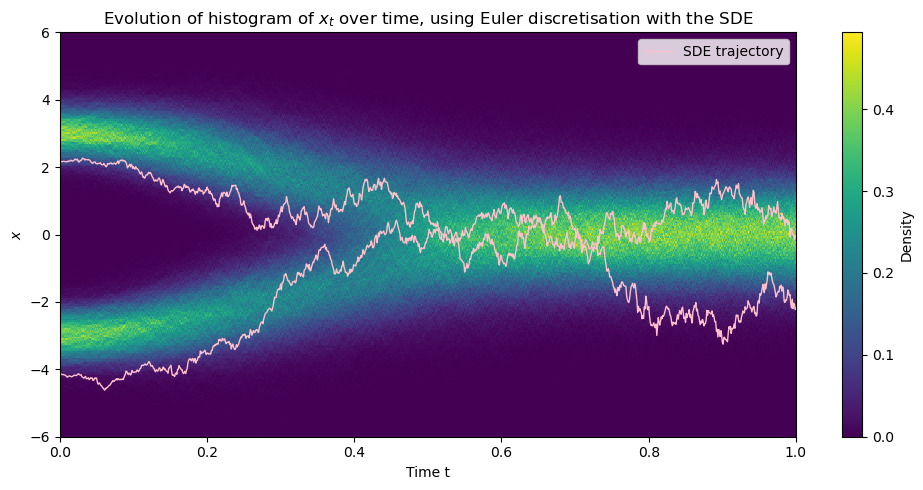

In [130]:
traj = diffuse(N, T, dt)

def plot_evolution(traj, adv_type, idx1 = 2000, idx2 = 5000):
    bins = np.linspace(-6, 6, 251)                       # 250 bins
    bin_c = 0.5*(bins[:-1] + bins[1:])                   # bin centres
    hist2d = np.empty((len(bin_c), T+1), dtype=np.float32)
    
    for k in range(T+1):
        h, _ = np.histogram(traj[k].numpy(), bins=bins, density=True)
        hist2d[:, k] = h
    
    fig, ax = plt.subplots(figsize=(10, 5))
    
    
    # NOTE: this might become points from the same side if the trajectories are reproduced
    path1 = traj[:, idx1]
    path2 = traj[:, idx2]
    
    im = ax.imshow(
        hist2d,                                          
        origin="lower",
        aspect="auto",
        interpolation="nearest",
        extent=[0, 1, bins[0], bins[-1]],             
        cmap="viridis"
    )
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Density")
    
    # overlay paths
    t_axis = np.linspace(0, 1, T+1)
    
    # two points from different sides of the mixture
    ax.plot(t_axis, path1, color="pink",  lw=1, label=f'{adv_type} trajectory')
    ax.plot(t_axis, path2, color="pink",  lw=1)
    
    ax.set_title(f"Evolution of histogram of $x_t$ over time, using Euler discretisation with the {adv_type}")
    ax.set_xlabel("Time t")
    ax.set_ylabel("$x$")
    plt.tight_layout()
    plt.legend()
    plt.show()

plot_evolution(traj, 'SDE')

### Section 4 - Forward ODE

Let's repeat the steps that we have seen in the tutorial. First denote the drift of the reverse SDE:
$$
\hat{\mu}(x_{\tau},\tau) =\mu(x_{\tau},\tau)\;-\frac12\;\sigma^{2}(\tau)\,\nabla_{x_{\tau}}\log p_{\tau}(x_{\tau})
$$
And according to the SDE of the DDPM, we have:
$$
\mu(x_{\tau},\tau)=-\frac12 \beta_{\tau} x_{\tau} \quad , \quad \sigma_{\tau}^2 = \beta_{\tau}
$$
Next, remember the reverse-ODE we have achieved:
$$
d x_{\tau} \;=\; \hat{\mu}(x_{\tau},\tau)\,d\tau
$$
We will use the Euler's method to advance the samples according to this ODE, using $s_{\theta}(x_t, t)$ that we have trained

In [135]:
N = 10_000
x0 = data_distribution.sample(torch.Size([N, 1]))
x = x0.clone()
# to store the trajectory
traj = torch.empty((T+1, *tuple(x.shape)))
traj[0] = x0.clone()

# euler's method for ODE
t = 0
with torch.no_grad():
    for i in range(T):
        model.eval()
        # preparing input for the model
        time_feat = torch.full((x.size(0), 1), t, dtype=x.dtype, device=x.device)
        score = model(torch.cat([x.to(device), time_feat.to(device)], dim=1)).to('cpu')   # already s_theta
        
        beta_t = beta0 + ((beta1 - beta0) * t)
        drift = -0.5 * beta_t * x            
        x += (drift - 0.5 * beta_t * score) * dt
        t += dt
        traj[i+1] = x.clone()

print(f"Empirical Mean of the diffused samples: {traj[-1].mean().item()}")
print(f"Empirical Variance of the diffused samples: {traj[-1].var().item()}")

Empirical Mean of the diffused samples: -0.23502373695373535
Empirical Variance of the diffused samples: 2.1035003662109375


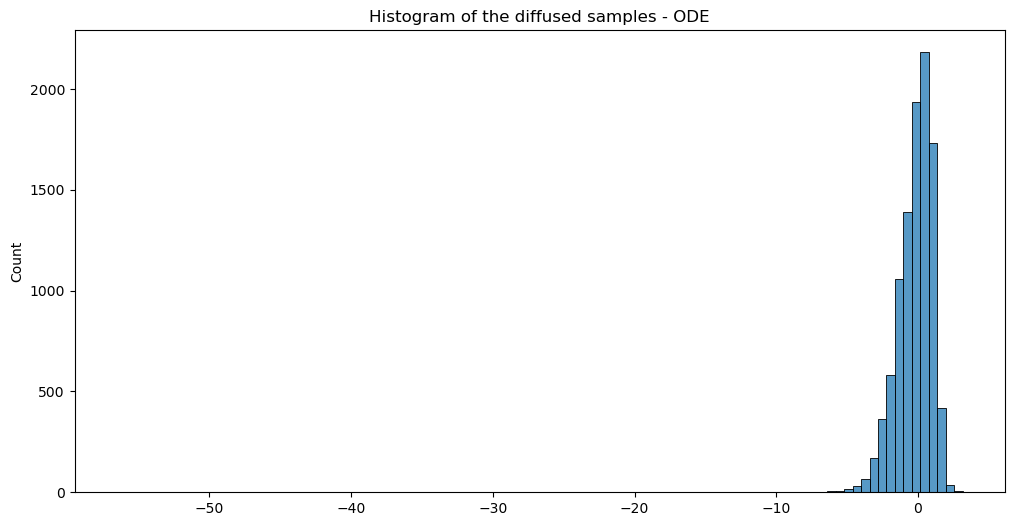

In [136]:
# plot the resulting samples
plt.figure(figsize=(12,6))
sns.histplot(traj[-1][:, 0], bins=100)
plt.title('Histogram of the diffused samples - ODE')
plt.show()

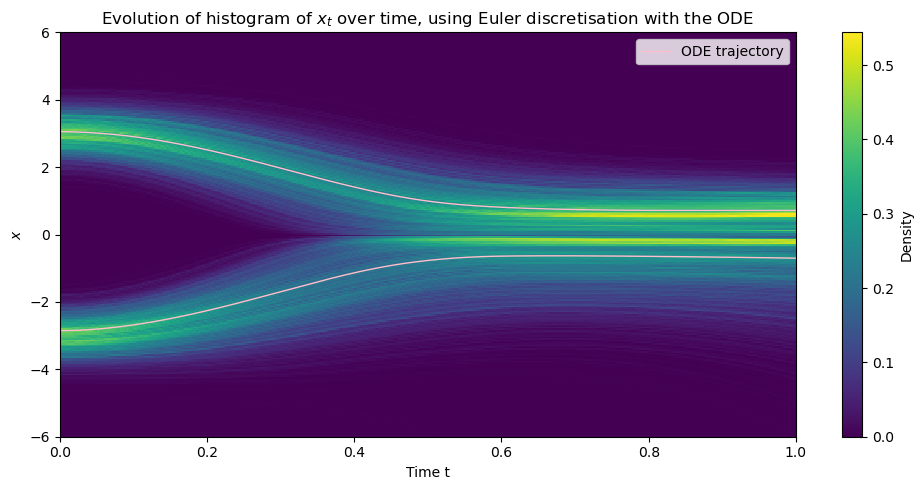

In [137]:
plot_evolution(traj, 'ODE')

We see that the ODE forward equation doesn't achieve results of the same quality as the SDE and we have a "dead" region at the infinitesimal region around 0. Also the histogram and the empirical parameters of the final distribution don't look as good.

### Section 5 - Reverse SDE

In [13]:
N = 10_000
x0 = torch.randn(N, 1)
x = x0.clone()
# to store the trajectory
traj = torch.empty((T+1, *tuple(x.shape)))
traj[T] = x0.clone()

# euler's method for ODE
with torch.no_grad():
    for i in range(T, -1, -1):
        model.eval()
        t = i * dt
        # preparing input for the model
        time_feat = torch.full((x.size(0), 1), t, dtype=x.dtype, device=x.device)
        score = model(torch.cat([x.to(device), time_feat.to(device)], dim=1)).to('cpu')   # already s_theta
        
        beta_t = beta0 + ((beta1 - beta0) * t)
        drift = 0.5 * beta_t * x            
        x += (drift + beta_t * score) * dt + (np.sqrt(beta_t * dt) * torch.randn_like(x))
        traj[i-1] = x.clone()

print(f"Empirical Mean of the diffused samples: {traj[-1].mean().item()}")
print(f"Empirical Variance of the diffused samples: {traj[-1].var().item()}")

Empirical Mean of the diffused samples: 0.23608222603797913
Empirical Variance of the diffused samples: 9.155574798583984


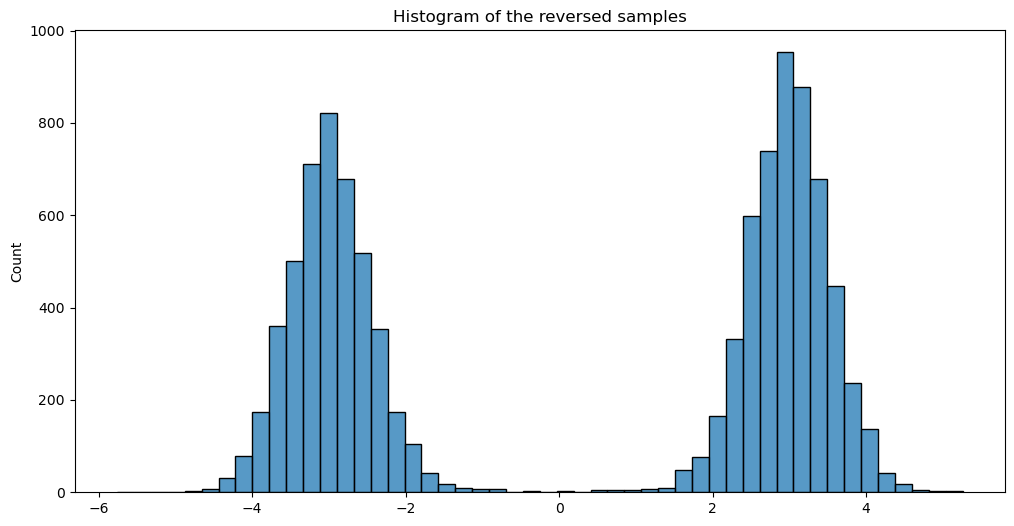

In [14]:
# plot the resulting samples
plt.figure(figsize=(12,6))
sns.histplot(traj[-1][:, 0], bins=50)
plt.title('Histogram of the reversed samples')
plt.show()

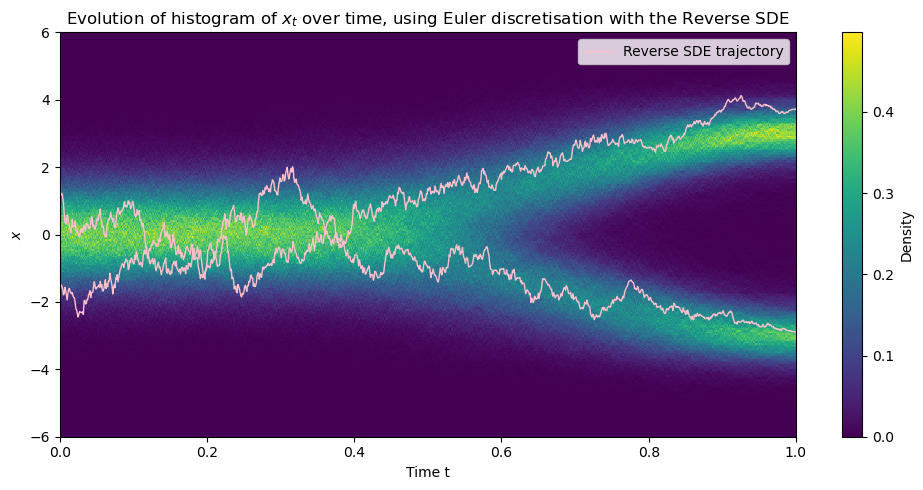

In [15]:
traj = torch.flip(traj, dims=[0])
plot_evolution(traj, 'Reverse SDE')

Visually, the reverse SDE indeed achieves the initial distribution!

## Part 2: Implementing DDPM as a Score Network

This part (and all following parts) will require a GPU, so you should run it on the machines we provided.

Note that parts 2 and 3 should heavily rely on your existing DDPM code. Not much has to change.

In the recent tutorials, we showed how the training procedures for DDPM and ALD are actually equivalent, and that using a basic transformation, we can view a model trained according to the DDPM loss as a model that approximates the score. In this part we will show how this is true.
1. Train a DDPM model the same way you trained in HW2, using either MNIST from HW1 (recommended) or Fashion MNIST from HW2. The only difference should be that time ($t$) should be between 0 and 1 as opposed to 1 and $T$. Note that because the time is now of a different scale, we may need to use a different method for time encoding. For now, $\beta(t) = \beta_{t*T}$. `beta0=1e-4, beta1=0.02` (remember that for discrete beta, the values are 1000 times smaller because we are not using the integral method).
2. Fill in the function ```get_score_model``` that accepts a model that was trained according to the DDPM loss and returns a new model that approximates the score (note that this is a nested function, meaning it returns a function).
3. Sample from the model using the score model, using what we saw in tutorials 5/6 and the sampling method above, or using Ancestral Sampling (shown in Equation 4 in the paper linked in part 1 and in tutorial 4). Display 64 sampled images.

### Section 1 - Training the UNet for DDPM

In [88]:
import math
from inspect import isfunction
from functools import partial

%matplotlib inline
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from einops import rearrange

import torch
from torch import nn, einsum
import torch.nn.functional as F

device = 'cuda' if torch.cuda.is_available() else 'cpu'

#### Network Helpers

In [89]:
def exists(x):
    return x is not None

def default(val, d):
    if exists(val):
        return val
    return d() if isfunction(d) else d

class Residual(nn.Module):
    """
    simply adds the input to the output of a particular function
    """
    def __init__(self, fn):
        super().__init__()
        self.fn = fn

    def forward(self, x, *args, **kwargs):
        return self.fn(x, *args, **kwargs) + x

def Upsample(dim):
    return nn.ConvTranspose2d(dim, dim, 4, 2, 1)

def Downsample(dim):
    return nn.Conv2d(dim, dim, 4, 2, 1)

#### Time Embeddings

In [90]:
class SinusoidalPositionEmbeddings(nn.Module):
    """
    Sinusoidal position embeddings, as described in the paper
    """

    def __init__(self, dim):
        """
        :param dim: int, the dimension of the embeddings
        """
        super().__init__()
        self.dim = dim

    def forward(self, time):
        """
        :param time: torch Tenseor of shape (batch_size, 1)
        :return: torch Tensor of shape (batch_size, dim)
        """
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        if self.dim % 2 == 1:  # zero pad
            embeddings = F.pad(embeddings, (0, 1), mode='constant')
        assert embeddings.shape == (time.shape[0], self.dim)
        return embeddings

In [91]:
class GaussianFourierProjection(nn.Module):
    def __init__(self, embed_dim: int, scale: float = 30.0):
        super().__init__()
        self.W = nn.Parameter(
            torch.randn(embed_dim // 2) * scale, requires_grad=False
        )

    def forward(self, t: torch.Tensor):             
        if t.dim() == 1:
            t = t[:, None]
        # (B, embed_dim/2)
        angles = t * self.W[None, :] * 2 * math.pi
        return torch.cat([angles.sin(), angles.cos()], dim=-1)

#### ResNet block

In [92]:
class Block(nn.Module):
    def __init__(self, dim, dim_out, groups = 8):
        super().__init__()
        self.proj = nn.Conv2d(dim, dim_out, 3, padding = 1)
        self.norm = nn.GroupNorm(groups, dim_out)
        self.act = nn.SiLU()

    def forward(self, x, scale_shift = None):
        x = self.proj(x)
        x = self.norm(x)

        if exists(scale_shift):
            scale, shift = scale_shift
            x = x * (scale + 1) + shift

        x = self.act(x)
        return x

class ResnetBlock(nn.Module):

    def __init__(self, dim, dim_out, *, time_emb_dim=None, groups=8):
        super().__init__()
        self.mlp = (
            nn.Sequential(nn.SiLU(), nn.Linear(time_emb_dim, dim_out))
            if exists(time_emb_dim)
            else None
        )

        self.block1 = Block(dim, dim_out, groups=groups)
        self.block2 = Block(dim_out, dim_out, groups=groups)
        self.res_conv = nn.Conv2d(dim, dim_out, 1) if dim != dim_out else nn.Identity()

    def forward(self, x, time_emb=None):
        h = self.block1(x)

        if exists(self.mlp) and exists(time_emb):
            time_emb = self.mlp(time_emb)
            h = rearrange(time_emb, "b c -> b c 1 1") + h

        h = self.block2(h)
        return h + self.res_conv(x)


#### Attention module

In [93]:
class Attention(nn.Module):
    def __init__(self, dim, heads=4, dim_head=32):
        super().__init__()
        self.scale = dim_head**-0.5
        self.heads = heads
        hidden_dim = dim_head * heads
        self.to_qkv = nn.Conv2d(dim, hidden_dim * 3, 1, bias=False)
        self.to_out = nn.Conv2d(hidden_dim, dim, 1)

    def forward(self, x):
        b, c, h, w = x.shape
        qkv = self.to_qkv(x).chunk(3, dim=1)
        q, k, v = map(
            lambda t: rearrange(t, "b (h c) x y -> b h c (x y)", h=self.heads), qkv
        )
        q = q * self.scale

        sim = einsum("b h d i, b h d j -> b h i j", q, k)
        sim = sim - sim.amax(dim=-1, keepdim=True).detach()
        attn = sim.softmax(dim=-1)

        out = einsum("b h i j, b h d j -> b h i d", attn, v)
        out = rearrange(out, "b h (x y) d -> b (h d) x y", x=h, y=w)
        return self.to_out(out)

class LinearAttention(nn.Module):
    def __init__(self, dim, heads=4, dim_head=32):
        super().__init__()
        self.scale = dim_head**-0.5
        self.heads = heads
        hidden_dim = dim_head * heads
        self.to_qkv = nn.Conv2d(dim, hidden_dim * 3, 1, bias=False)

        self.to_out = nn.Sequential(nn.Conv2d(hidden_dim, dim, 1),
                                    nn.GroupNorm(1, dim))

    def forward(self, x):
        b, c, h, w = x.shape
        qkv = self.to_qkv(x).chunk(3, dim=1)
        q, k, v = map(
            lambda t: rearrange(t, "b (h c) x y -> b h c (x y)", h=self.heads), qkv
        )

        q = q.softmax(dim=-2)
        k = k.softmax(dim=-1)

        q = q * self.scale
        context = torch.einsum("b h d n, b h e n -> b h d e", k, v)

        out = torch.einsum("b h d e, b h d n -> b h e n", context, q)
        out = rearrange(out, "b h c (x y) -> b (h c) x y", h=self.heads, x=h, y=w)
        return self.to_out(out)

#### Group normalization

In [94]:
class PreNorm(nn.Module):
    def __init__(self, dim, fn):
        super().__init__()
        self.fn = fn
        self.norm = nn.GroupNorm(1, dim)

    def forward(self, x):
        x = self.norm(x)
        return self.fn(x)

#### U-Net

In [95]:
class Unet(nn.Module):
    """
    Unet architecture for diffusion models
    the network takes a batch of noisy images of shape (batch_size, num_channels, height, width)
    and a batch of noise levels of shape (batch_size, 1) as input
    and returns a tensor of shape (batch_size, num_channels, height, width)
    """
    def __init__(
        self,
        dim,
        sin,
        init_dim=None,
        out_dim=None,
        dim_mults=(1, 2, 4,),
        channels=3,
        with_time_emb=True,
        resnet_block_groups=1
    ):
        super().__init__()

        #### ADD YOUR CODE HERE ####
        self.channels = channels
        init_dim = default(init_dim, dim)
        self.init_conv = nn.Conv2d(channels, init_dim, 7, padding=3)

        dims = [init_dim, *map(lambda m: dim * m, dim_mults)]
        in_out = list(zip(dims[:-1], dims[1:]))

        if with_time_emb:
            time_dim = dim * 4
            if sin:
                self.time_mlp = nn.Sequential(
                    SinusoidalPositionEmbeddings(dim),
                    nn.Linear(dim, time_dim),
                    nn.SiLU(),
                    nn.Linear(time_dim, time_dim)
                )
            else:
                self.time_mlp = nn.Sequential(
                    GaussianFourierProjection(dim),
                    nn.Linear(dim, time_dim),
                    nn.SiLU(),
                    nn.Linear(time_dim, time_dim)
                )
        else:
            time_dim = None
            self.time_mlp = None

        self.downs = nn.ModuleList([])
        self.ups = nn.ModuleList([])
        num_resolutions = len(in_out)

        for ind, (dim_in, dim_out) in enumerate(in_out):
            self.downs.append(nn.ModuleList([
                ResnetBlock(dim_in, dim_out, time_emb_dim=time_dim, groups=resnet_block_groups),
                ResnetBlock(dim_out, dim_out, time_emb_dim=time_dim, groups=resnet_block_groups),
                Residual(PreNorm(dim_out, LinearAttention(dim_out))),
                Downsample(dim_out) if ind < num_resolutions - 1 else nn.Identity()
            ]))

        mid_dim = dims[-1]
        self.mid_block1 = ResnetBlock(mid_dim, mid_dim, time_emb_dim=time_dim, groups=resnet_block_groups)
        self.mid_attn = Residual(PreNorm(mid_dim, Attention(mid_dim)))
        self.mid_block2 = ResnetBlock(mid_dim, mid_dim, time_emb_dim=time_dim, groups=resnet_block_groups)

        for ind, (dim_in, dim_out) in enumerate(reversed(in_out)):
            self.ups.append(nn.ModuleList([
                ResnetBlock(dim_out * 2, dim_in, time_emb_dim=time_dim, groups=resnet_block_groups),
                ResnetBlock(dim_in, dim_in, time_emb_dim=time_dim, groups=resnet_block_groups),
                Residual(PreNorm(dim_in, LinearAttention(dim_in))),
                Upsample(dim_in) if ind < num_resolutions - 1 else nn.Identity()
            ]))

        out_dim = default(out_dim, channels)
        self.final_res_block = ResnetBlock(dim, dim, time_emb_dim=time_dim, groups=resnet_block_groups)
        self.final_conv = nn.Conv2d(dim, out_dim, 1)
        #### DONE WITH SOLUTION ####


    def forward(self, x, time):
        """
        :param x: torch Tensor of shape (batch_size, channels, height, width)
        :param time: torch Tensor of shape (batch_size, 1)
        :return: torch Tensor of shape (batch_size, channels, height, width)
        """

        #### ADD YOUR CODE HERE ####
        x = self.init_conv(x)
        r = x.clone()

        t = self.time_mlp(time) if exists(self.time_mlp) else None

        h = []

        # Downsampling path
        for resnet1, resnet2, attn, downsample in self.downs:
            x = resnet1(x, t)
            x = resnet2(x, t)
            x = attn(x)
            h.append(x)
            x = downsample(x)

        # Bottleneck
        x = self.mid_block1(x, t)
        x = self.mid_attn(x)
        x = self.mid_block2(x, t)

        # Upsampling path
        for resnet1, resnet2, attn, upsample in self.ups:
            x = torch.cat((x, h.pop()), dim=1)
            x = resnet1(x, t)
            x = resnet2(x, t)
            x = attn(x)
            x = upsample(x)

        x = self.final_res_block(x, t)
        return self.final_conv(x)
        #### DONE WITH SOLUTION ####

#### $\beta$ schedules

In [96]:
def linear_beta_schedule(timesteps):
    """
    set the forward process variances to constants
    increasing linearly from beta_1 = 0.0001 to beta_T = 0.02.
    :param timesteps: int
    :return: torch Tensor of shape (timesteps,)
    """
    #### ADD YOUR CODE HERE ####
    beta_start = 0.0001
    beta_end = 0.02
    #### DONE WITH SOLUTION ####
    return torch.linspace(beta_start, beta_end, timesteps)

def cosine_beta_schedule(timesteps, s=0.008):
    """
    cosine schedule ([Nichol et al., 2021](https://arxiv.org/abs/2102.09672))
    :param timesteps: int
    :param s: float
    :return: torch Tensor of shape (timesteps,)
    """
    #### ADD YOUR CODE HERE ####

    steps = timesteps + 1
    x = torch.linspace(0, timesteps, steps) / timesteps
    alphas_bar = torch.cos((x + s) / (1 + s) * math.pi / 2) ** 2
    alphas_bar = alphas_bar / alphas_bar[0]  # normalize so that alpha_bar[0] == 1

    betas = 1 - (alphas_bar[1:] / alphas_bar[:-1])

    #### DONE WITH SOLUTION ####
    return torch.clip(betas, 0.0001, 0.9999)

#### $\beta$ utilities

In [97]:
timesteps = 1000

# define beta schedule
betas = linear_beta_schedule(timesteps=timesteps)

# define alphas
alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)
alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)
sqrt_recip_alphas = 1. / torch.sqrt(alphas)

# calculations for diffusion q(x_t | x_{t-1}) and others
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod)

# calculations for posterior q(x_{t-1} | x_t, x_0)
posterior_variance = betas * (1. - alphas_cumprod_prev) / (1. - alphas_cumprod)

def extract(a, t, x_shape):
    # extracts the appropriate $t$ index for a batch of indices
    batch_size = t.shape[0]
    out = a.gather(-1, t.cpu())
    return out.reshape(batch_size, *((1,) * (len(x_shape) - 1))).to(t.device)

#### Sampling (for training only - as in HW2) and the Loss

In [98]:
def q_sample(x_start, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x_start)

    # get the appropriate beta schedule
    sqrt_alphas_cumprod_t = extract(sqrt_alphas_cumprod, t, x_start.shape)
    sqrt_one_minus_alphas_cumprod_t = extract(sqrt_one_minus_alphas_cumprod, t, x_start.shape)

    # calculate the forward process
    x_t = (sqrt_alphas_cumprod_t * x_start) + (sqrt_one_minus_alphas_cumprod_t * noise)
    return x_t

def p_losses(denoise_model, x_start, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x_start)

    # get the appropriate beta schedule
    x_with_noise = q_sample(x_start, t, noise=noise)
    predicted_noise = denoise_model(x_with_noise, (t / timesteps))   # the model is "fed" the values from 0 to 1
    loss = F.mse_loss(noise, predicted_noise)

    return loss

#### Dataset and Dataloader

In [99]:
from datasets import load_dataset
from torchvision import transforms
from torch.utils.data import DataLoader

#### ADD YOUR CODE HERE ####

# hyper-paramaters
IMG_SIZE = 28
LR = 1e-3
BATCH_SIZE = 128
NUM_EPOCHS = 60


class FashionMNISTDataset(torch.utils.data.Dataset):
    def __init__(self, split='train', transform=None):
        self.dataset = load_dataset('mnist', split=split)
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image = self.dataset[idx]['image']
        if self.transform:
            image = self.transform(image)
        return image
# transformations
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda t: (t * 2) - 1),  # scale to [-1, 1]
])
# final dataset and loader
train_dataset = FashionMNISTDataset(split='train', transform=transform)
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
#### DONE WITH SOLUTION ####


#### Training

In [100]:
from torchvision.utils import save_image
from tqdm import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"

# change it if working with a different loss
def train_model(model, optimizer, train_loader, model_name, num_epochs = NUM_EPOCHS, device=device, epoch_start=0):
    path_name = f'checkpoints/HW3/{model_name}'
    loss_steps = list()
    bar = tqdm(range(num_epochs))
    for epoch in bar:
        loss_accum = 0
        model.train()
        loss_accum = 0
        for batch in train_loader:
            t = torch.randint(0, timesteps, (batch.shape[0],), device=device).long()
            loss = p_losses(model, batch.to(device), t.to(device))
            bar.set_postfix({'Loss':loss.item()})
            loss_accum += loss.item()
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        # report batch loss
        loss_accum = loss_accum / len(train_loader)
        bar.set_postfix({'Loss':loss_accum})
        loss_steps.append(loss_accum)
        
        if (epoch + 1) % 5 == 0:
            print(f"Epoch: {epoch+1}, Loss: {loss_accum}")
        if (epoch + 1) % 5 == 0:
            torch.save({'model': model.state_dict(), 'optim': optimizer.state_dict(), 'epoch': epoch},\
                       f"{path_name}_chkpt{epoch+epoch_start+1}.pth")
            
    model = model.to('cpu')   # putting the model back to cpu
    return loss_steps   # returning loss steps because the model is saved

In [102]:
channels = 1
model = Unet(
    sin=True,
    dim=IMG_SIZE,
    channels=channels,
    dim_mults=(1, 2, 4)
)
epoch_start=0
model.to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# uncomment if training from a checkpoint
# chkpt_path = 'checkpoints/HW3/model_discrete_ddpm_chkpt60.pth'
# chkpt = torch.load(chkpt_path)
# model.load_state_dict(chkpt['model'])
# optimizer.load_state_dict(chkpt['optim'])
# epoch_start = chkpt['epoch']
# print(f'Continuing training the model fromm epoch: {epoch_start}, Epochs to go: {NUM_EPOCHS}')

loss_steps = train_model(model, optimizer, train_dataloader, model_name='model_discrete_ddpm_sintime', epoch_start=epoch_start)

  8%|▊         | 5/60 [04:24<48:41, 53.11s/it, Loss=0.0287]

Epoch: 5, Loss: 0.028662630918819005


 17%|█▋        | 10/60 [08:51<44:27, 53.35s/it, Loss=0.0247]

Epoch: 10, Loss: 0.024703390864548144


 25%|██▌       | 15/60 [13:12<39:25, 52.56s/it, Loss=0.0236]

...

Epoch: 50, Loss: 0.021502327211677774


 92%|█████████▏| 55/60 [48:32<04:23, 52.63s/it, Loss=0.0211]

Epoch: 55, Loss: 0.021149909739364692


100%|██████████| 60/60 [52:59<00:00, 53.00s/it, Loss=0.0212]

Epoch: 60, Loss: 0.021167502994698755


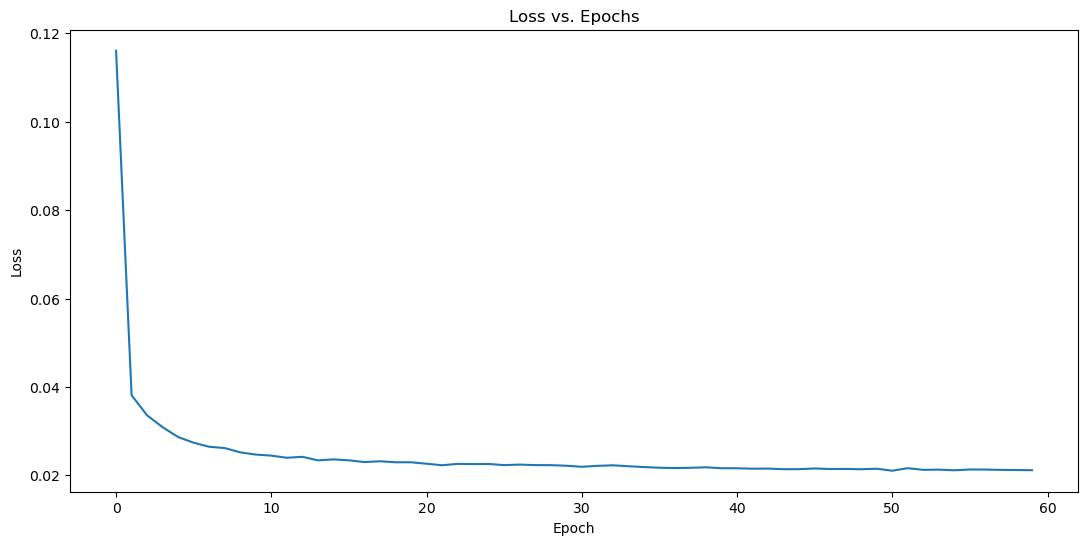

In [103]:
# plotting the loss steps
plt.figure(figsize=(13, 6))
plt.plot(list(range(len(loss_steps))), loss_steps)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs. Epochs')
plt.plot()
plt.show()

Just continuing training to achieve better results

In [129]:
channels = 1
model = Unet(
    sin=True,
    dim=IMG_SIZE,
    channels=channels,
    dim_mults=(1, 2, 4)
)
epoch_start=0
model.to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# uncomment if training from a checkpoint
chkpt_path = 'checkpoints/HW3/model_discrete_ddpm_sintime_chkpt74.pth'
chkpt = torch.load(chkpt_path, weights_only=True)
model.load_state_dict(chkpt['model'])
optimizer.load_state_dict(chkpt['optim'])
epoch_start = chkpt['epoch']
print(f'Continuing training the model fromm epoch: {epoch_start+1}')

_ = train_model(model, optimizer, train_dataloader, model_name='model_discrete_ddpm_sintime', num_epochs=15, epoch_start=epoch_start)

Continuing training the model fromm epoch: 60


 33%|███▎      | 5/15 [03:04<06:09, 36.98s/it, Loss=0.0216]

Epoch: 5, Loss: 0.02156278408588247


 67%|██████▋   | 10/15 [06:09<03:05, 37.04s/it, Loss=0.0215]

Epoch: 10, Loss: 0.021509598797940194


100%|██████████| 15/15 [09:14<00:00, 36.99s/it, Loss=0.0215]

Epoch: 15, Loss: 0.02152476063434114


#### Sampling with the score

In [78]:
# loading from a checkpoint
channels = 1
model = Unet(
    sin=True,
    dim=IMG_SIZE,
    channels=channels,
    dim_mults=(1, 2, 4)
)
chkpt_path = 'checkpoints/HW3/model_discrete_ddpm_sintime_chkpt64.pth'
chkpt = torch.load(chkpt_path, weights_only=True)
model.load_state_dict(chkpt['model'])
model = model.to(device)

In [104]:
from tqdm import tqdm

betas = linear_beta_schedule(timesteps)
model.to(device)

def get_sqrt_1m_alpha(t):
    return sqrt_one_minus_alphas_cumprod.to(device)[(t * timesteps).int()]

def get_score_model(ddpm_model, ddpm_sqrt_1m_alpha):
    def score(x_t, t):
        # YOUR CODE HERE
        with torch.no_grad():
            ddpm_model.eval()
            eps_hat = ddpm_model(x_t, t)
            sigma_t = ddpm_sqrt_1m_alpha(t).view(-1, 1, 1, 1)
        return -eps_hat / sigma_t 
    return score

In [80]:
def sde_sampler(score_fn, shape, device, n_steps: int = 1000):
    
    B, C, H, W = shape
    x = torch.randn(shape)

    dt = 1 / n_steps                  
    bar = tqdm(reversed(range(n_steps)), total=n_steps)
    for j, t in enumerate(bar):
        t_norm = torch.tensor(t / n_steps).expand(B)
        beta_t = (betas * n_steps)[t]   # fix the scale of betas
    
        if j == n_steps - 1:   # last step is deterministic
            sqrt_beta_dt = 0
        else:
            sqrt_beta_dt = torch.sqrt(beta_t * dt)

        # reverse drift
        drift = (-0.5 * beta_t * x) + (beta_t * score_fn(x.to(device), t_norm.to(device)).to('cpu'))

        noise = torch.randn_like(x)

        # euler update
        x = x + (drift * dt) + (sqrt_beta_dt * noise)

    return x

In [105]:
def ancestral_sampler(score_fn, shape, device, n_steps=1000):

    B, _, _, _ = shape
    x = torch.randn(shape)
    
    with torch.no_grad():
        for i in tqdm(reversed(range(n_steps)), total=n_steps):
            beta_i = betas[i]
            t_norm = torch.tensor(i).expand(B) / n_steps
    
            score_pred = score_fn(x.to(device), t_norm.to(device)).to('cpu')
            mean_cond = (1 / torch.sqrt(1-beta_i)) * (x + beta_i*score_pred)
            std_cond = torch.sqrt(beta_i)

            if i > 0:
                x = mean_cond + std_cond * torch.randn_like(x)
            else:
                x = mean_cond

    return x.clamp(-1, 1)

In [106]:
from torchvision.utils import save_image

def sample(model, path_name=f'images/HW3/tmp2.png'):
    score_fn = get_score_model(model, get_sqrt_1m_alpha)
    # samples = sde_sampler(score_fn, (64, 1, 28, 28), device)
    samples = ancestral_sampler(score_fn, (64, 1, 28, 28), device)
    saved = samples
    saved = (saved + 1) * 0.5
    saved = saved.clamp(0, 1)
    save_image(saved, path_name)

100%|██████████| 1000/1000 [00:33<00:00, 30.08it/s]


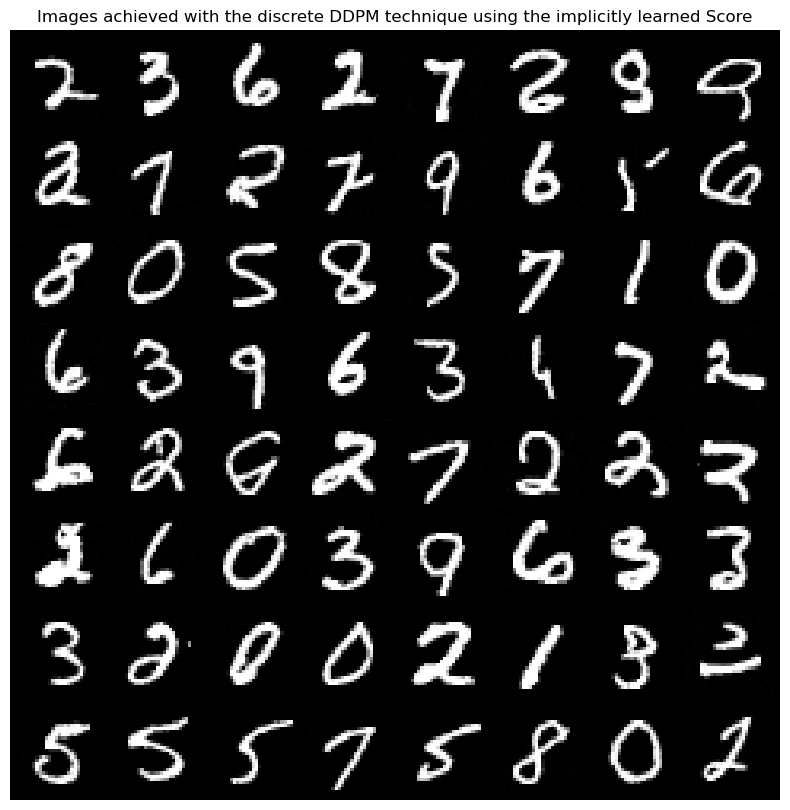

In [108]:
import matplotlib.image as im

sample(model)
img = im.imread('images/HW3/tmp2.png')
# img = im.imread('images/HW3/part2_imgs.png')
plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.title('Images achieved with the discrete DDPM technique using the implicitly learned Score')
plt.axis('off')
plt.show()

In this part, we saw that the DDPM technique implicitly approximates the score. I trained the noise predictor and used the implicitly learned score to generate images according to the Ancestral sampling and indeed we can see that we get images from the MNIST distribution as a result of this sampling procedure

## Part 3: True SDE Implementation

In the previous part, we still used the $\alpha_t$ notations. Now, we will get rid of them and instead implement a true SDE based model, based on the DDPM SDE (variance preserving). We assume a linear $\beta_t$ schedule like before, meaning that the integral to compute the conditional mean can be computed. Remember that now the continuous transformation of $\beta_t$ is $\beta(t)=T\beta_i$ for $i=Tt$. Tip: remember that the continuous version's means should be similar to $\alpha_i$ in the discrete case.

1. Fill in the classes `DDPM_SDE`, `UnifiedLoss`. For the loss, you can either use the score matching loss (less recommended) or the regular noise matching loss. If you use the noise matching loss, implement a function `get_score_model_continuous(model, sde)` that transforms your model that approximates noise to a model that approximates the score. Remember that for $t=0$, we may have a problem defining the std=0, so we can define a small std instead. Implement `train_sde`. 
2. Fill in the class `AncestralSamplingContinuous`. This class can either sample using what we saw in part 2 or using Euler's method on the reverse DDPM SDE as implemented in part 1. Implement `sample_images` which should denoise images. Note that the final sampling step should add 0 noise.

Again, note that not much has to change in this part, except now $\beta$ should be implemented as a function and not a sequence, $\alpha_t$ is replaced with the calculation from the tutorial.

In [65]:
from torch.distributions import Normal

In [66]:
class DDPM_SDE:
    def __init__(self, beta_0, beta_1, T_discrete, device):
        """beta_0, beta_1: The original beta_1, beta_T."""
        self.device = device
        self.beta_0 = beta_0
        self.beta_1 = beta_1
        self.T = T_discrete
        self.discrete_betas = torch.linspace(beta_0 / T_discrete, beta_1 / T_discrete, T_discrete)
        self.alphas = 1. - self.discrete_betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_1m_alphas_cumprod = torch.sqrt(1. - self.alphas_cumprod)

    def beta(self, t):
        """
        t in [0, 1], can be any real value in this interval and is not restricted to the discrete time steps. In reality, t is a batch vector.
        """
        return self.beta_0 + t * (self.beta_1 - self.beta_0)        

    def drift_diffusion(self, x_t, t):
        """
        x_t: (batch_size, channels, height, width)
        t: (batch_size,)

        Return the drift coefficient (mu) and the diffusion coefficient (sigma) of the SDE at time t and the current x_t.
        """
        beta_t = self.beta_0 + t * (self.beta_1 - self.beta_0)
        drift = -0.5 * beta_t[:, None, None, None] * x_t
        diffusion = torch.sqrt(beta_t)
        return drift, diffusion

    def distribution(self, x_0, t):
        """
        x_0: (batch_size, channels, height, width)
        t: (batch_size,)
        Return the distribution of x_t conditioned on x_0 and t.
        """
        log_mean_coeff = -0.25 * t ** 2 * (self.beta_1 - self.beta_0) - 0.5 * t * self.beta_0
        mean = torch.exp(log_mean_coeff)[:, None, None, None] * x_0
        std = torch.sqrt(1. - torch.exp(2. * log_mean_coeff))[:, None, None, None]
        std.clamp_min_(1e-12)
        dist = Normal(mean, std)
        return dist

    def reverse_drift_diffusion(self, score_fn, x_t, t):
        """
        score_fn: function that takes x_t and t and returns the score
        x_t: (batch_size, channels, height, width)
        t: (batch_size,)
        Return the drift coefficient (mu) and the diffusion coefficient (sigma) of the reverse SDE at time t and the current x_t.
        """

        # reverse drift as we have seen in the tutorial
        drift_reg, diffusion_reg = self.drift_diffusion(x_t, t)
        beta_t = self.beta(t)[:, None, None, None]
        drift = drift_reg - (beta_t * score_fn(x_t, t))

        return drift, diffusion_reg

In [67]:
class UnifiedLoss(nn.Module):
    def __init__(self, sde, model):
        super().__init__()
        self.sde = sde
        self.noise_model = model   # i chose to work with the noise matching model
                
    def forward(self, x):
        """
        x is a batch of images (batch_size, channels, height, width).
        """
        B, C, H, W = x.shape
        device = next(self.noise_model.parameters()).device

        # conditional mean and variance
        t = torch.rand(B, device=x.device) * 0.999 + 1e-3
        cond_dist = self.sde.distribution(x, t)
        mean, std = cond_dist.mean, cond_dist.scale

        # sample
        noise = torch.randn_like(x)
        x_t = mean + std * noise

        # denoise
        noise_theta = self.noise_model(x_t, t)
        return F.mse_loss(noise, noise_theta)

In [68]:
def get_score_model(noise_model, sde):
    noise_model.eval()
    def score_model(x_t, t):
        log_mean_coeff = -0.25 * t ** 2 * (sde.beta_1 - sde.beta_0) - 0.5 * t * sde.beta_0
        std = torch.sqrt(1. - torch.exp(2. * log_mean_coeff))
        with torch.no_grad():
            noise_pred = noise_model(x_t, t)
            # print(noise_pred.shape, std.shape)
            score =  -noise_pred / std.unsqueeze(-1).unsqueeze(-1).unsqueeze(-1)
            return score
    return score_model

In [69]:
class AncestralSamplingContinuous(nn.Module):
    def __init__(self, sde, noise_model):
        super().__init__()
        self.sde = sde
        self.noise_model = noise_model
        self.score_model = get_score_model(noise_model, self.sde)

    def forward(self, x_0):
        """
        x_0: (batch_size, channels, height, width). x_0 is the original noise.
        Remember that the final step of the SDE should not sample any random noise and should be deterministic.
        To know how many steps to do, use T_discrete from the SDE.
        x_0 is the original noise. Return a list of images for each 100 steps.
        """
        T = self.sde.T
        dt = -1.0 / T
        x  = x_0.to(device)
        snaps = []
        for i in tqdm(range(T)):
            t = torch.full((x.size(0),), 1.0 - i / T, device=x.device)
            mu_rev, sig_rev = self.sde.reverse_drift_diffusion(self.score_model, x, t.to(device))
            noise = torch.zeros_like(x, device=x.device) if (i == T - 1) else torch.randn_like(x, device=x.device)
            x = x + mu_rev * dt + sig_rev[:, None, None, None] * math.sqrt(-dt) * noise
            if (i % 100) == 0:
                snaps.append(x.cpu())
        snaps.append(x.cpu())
        return snaps
    

In [76]:
def train_sde(model, train_loader, loss_fn, optimizer, num_epochs, device, epoch_start=0):
    chkpt_path = 'checkpoints/HW3/sde_model'
    loss_steps = list()
    bar = tqdm(range(num_epochs))
    model.to(device)
    max_norm = 1.

    for epoch in bar:
        loss_accum = 0
        model.train()
        for batch in train_loader:
            B = batch.shape[0]
            optimizer.zero_grad()
            loss = loss_fn(batch.to(device))
            bar.set_postfix({'Loss': loss.item()})
            loss_accum += loss.item()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm)
            optimizer.step()
        loss_accum = loss_accum / len(train_loader)
        loss_steps.append(loss_accum)

        # print('Sampling!')
        # sample_images(model, device)
        
        if (epoch+1)%5 == 0:
            print(f"Epoch: {epoch+1}, Loss: {loss_accum}")

        if (epoch+1)%10 == 0:
            torch.save({'model': model.state_dict(), 'optim': optimizer.state_dict(), 'epoch': epoch},\
                       f"{chkpt_path}_chkpt{epoch+epoch_start+1}.pth")
    model.to('cpu')
    return loss_steps

In [77]:
def sample_images(model, device, num_imgs, path_name='images/HW3/tmp.png'):
    """
    Sample images according to the SDE, model and display / save them. Feel free to change this function as much as you'd like, the given implementation is for you.
    Remember if the model is a noise matching model, you should perform the transformation to turn it into a score model.
    """
    sde = DDPM_SDE(beta_0=BETA_0, beta_1=BETA_1, T_discrete=1000, device=device)  # Replace with the parameters of your SDE. These parameters should work, but feel free to change them if they don't work for you.
    sampler = AncestralSamplingContinuous(sde, model).to(device)

    noisy_images = torch.randn(num_imgs, 1, 28, 28)  # Replace with the shape of your images.
    with torch.no_grad():
        history = sampler(noisy_images)
    saved = history[-1].clone()
    saved = (saved + 1) * 0.5
    saved = saved.clamp(0, 1)
    save_image(saved, path_name)
    ### ADD CODE TO DISPLAY / SAVE THE IMAGES ###


In [79]:
from tqdm import tqdm

BETA_0 = 1e-1
BETA_1 = 20
T = 1000

sde = DDPM_SDE(BETA_0, BETA_1, T, device)
channels = 1
model = Unet(
    sin=True,
    dim=IMG_SIZE,
    channels=channels,
    dim_mults=(1, 2, 4)
)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = UnifiedLoss(sde, model).to(device)

loss_steps = train_sde(model, train_dataloader, loss_fn, optimizer, num_epochs=30, device=device)

 17%|█▋        | 5/30 [03:55<19:35, 47.03s/it, Loss=0.0272]

Epoch: 5, Loss: 0.02541409916619756


 33%|███▎      | 10/30 [07:49<15:37, 46.86s/it, Loss=0.0227]

Epoch: 10, Loss: 0.023257439485443298


 50%|█████     | 15/30 [11:44<11:44, 46.96s/it, Loss=0.0202]

...

Epoch: 20, Loss: 0.022102609566692858


 83%|████████▎ | 25/30 [19:34<03:54, 46.86s/it, Loss=0.0293]

Epoch: 25, Loss: 0.022126739056332154


100%|██████████| 30/30 [23:27<00:00, 46.93s/it, Loss=0.0223]

Epoch: 30, Loss: 0.021872422933927986


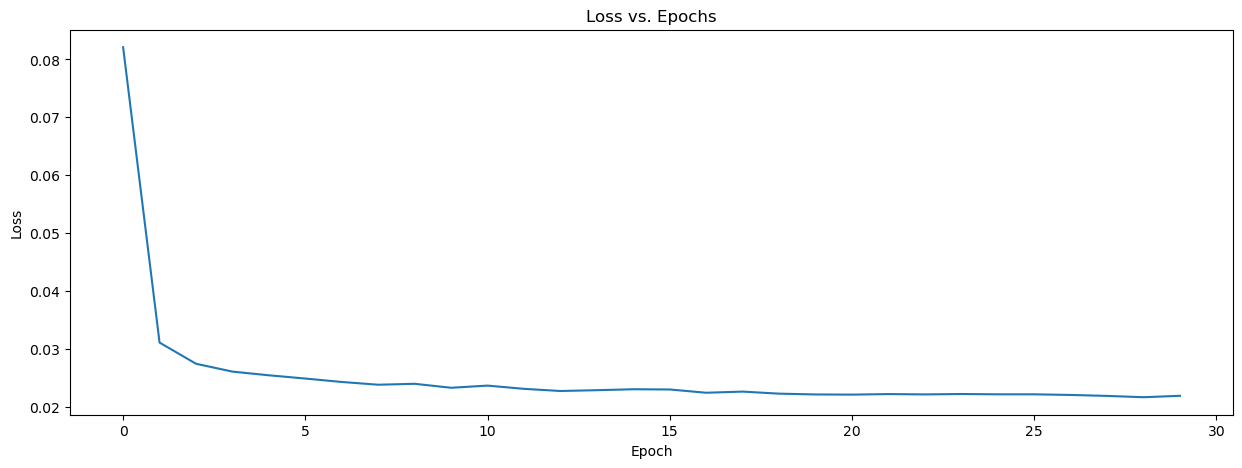

In [84]:
plt.figure(figsize=(15,5))
plt.plot(range(len(loss_steps)), loss_steps)
plt.title('Loss vs. Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

In [86]:
# saving 64 images for submission
sample_images(model, device, num_imgs=64)

100%|██████████| 1000/1000 [00:17<00:00, 57.60it/s]


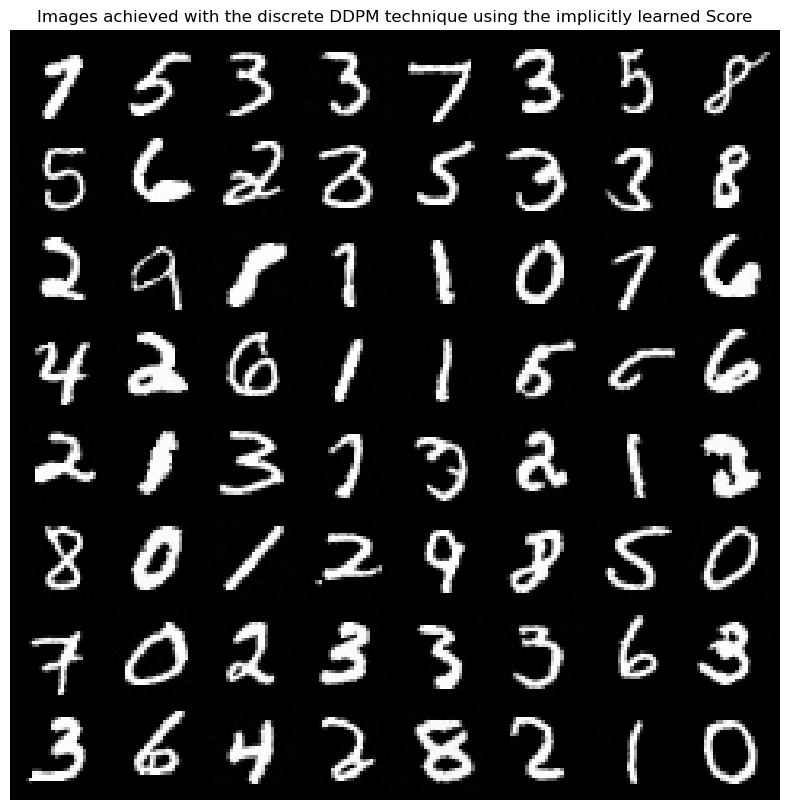

In [166]:
import matplotlib.image as im

img = im.imread('images/HW3/part3_imgs.png')

plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.title('Images achieved with the discrete DDPM technique using the implicitly learned Score')
plt.axis('off')
plt.show()

100%|██████████| 1000/1000 [00:16<00:00, 59.55it/s]


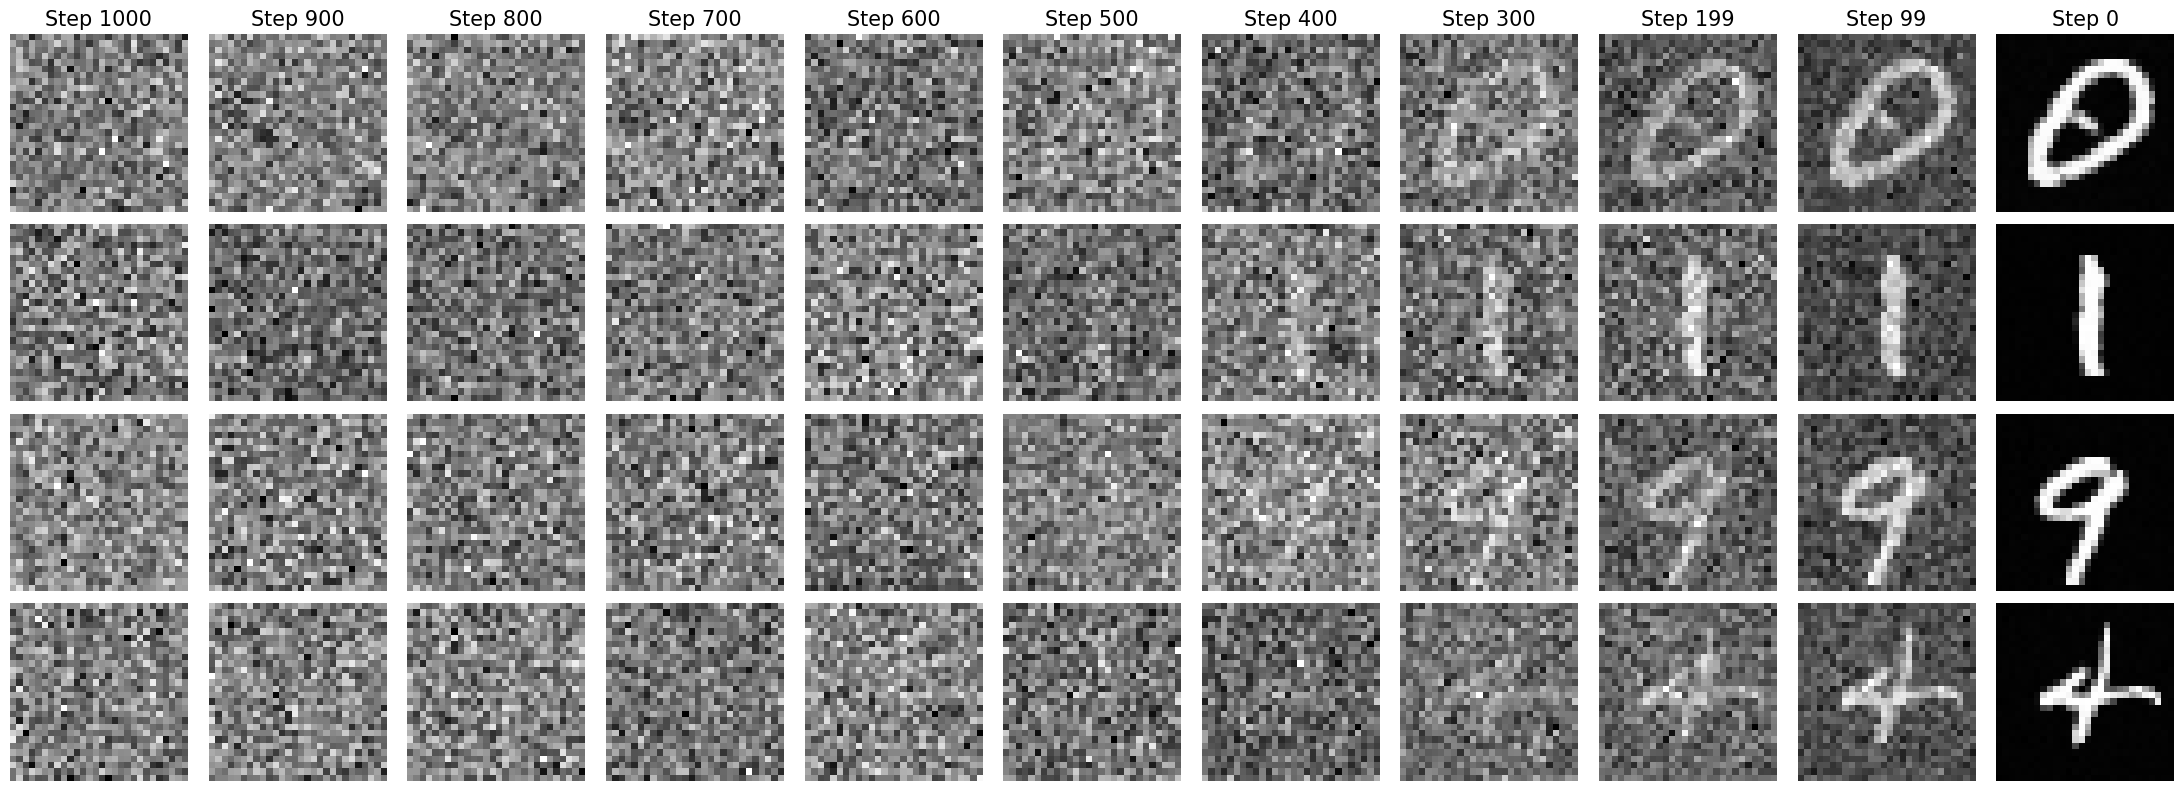

In [146]:
def viz_diffusion(num_imgs=4):
    x0 = torch.randn(num_imgs, 1, 28, 28, device=device)
    sampler = AncestralSamplingContinuous(sde, model).to(device)
    history = sampler(x0)           
    
    L = len(history)
    fig, axes = plt.subplots(num_imgs, L, figsize=(L * 2, num_imgs * 2))
    steps = [int((1 - i/(L-1)) * sampler.sde.T) for i in range(L)]
    
    for i in range(num_imgs):    
        for j in range(L):          
            ax = axes[i, j]         
            img = history[j][i, 0].cpu().numpy()
            ax.imshow(img, cmap='gray', interpolation='nearest')
            ax.axis('off')
            
            # step titles
            if i == 0:
                ax.set_title(f"Step {steps[j]}", fontsize=15)
    
    plt.tight_layout()
    plt.show()

viz_diffusion(num_imgs=4)

Example output:

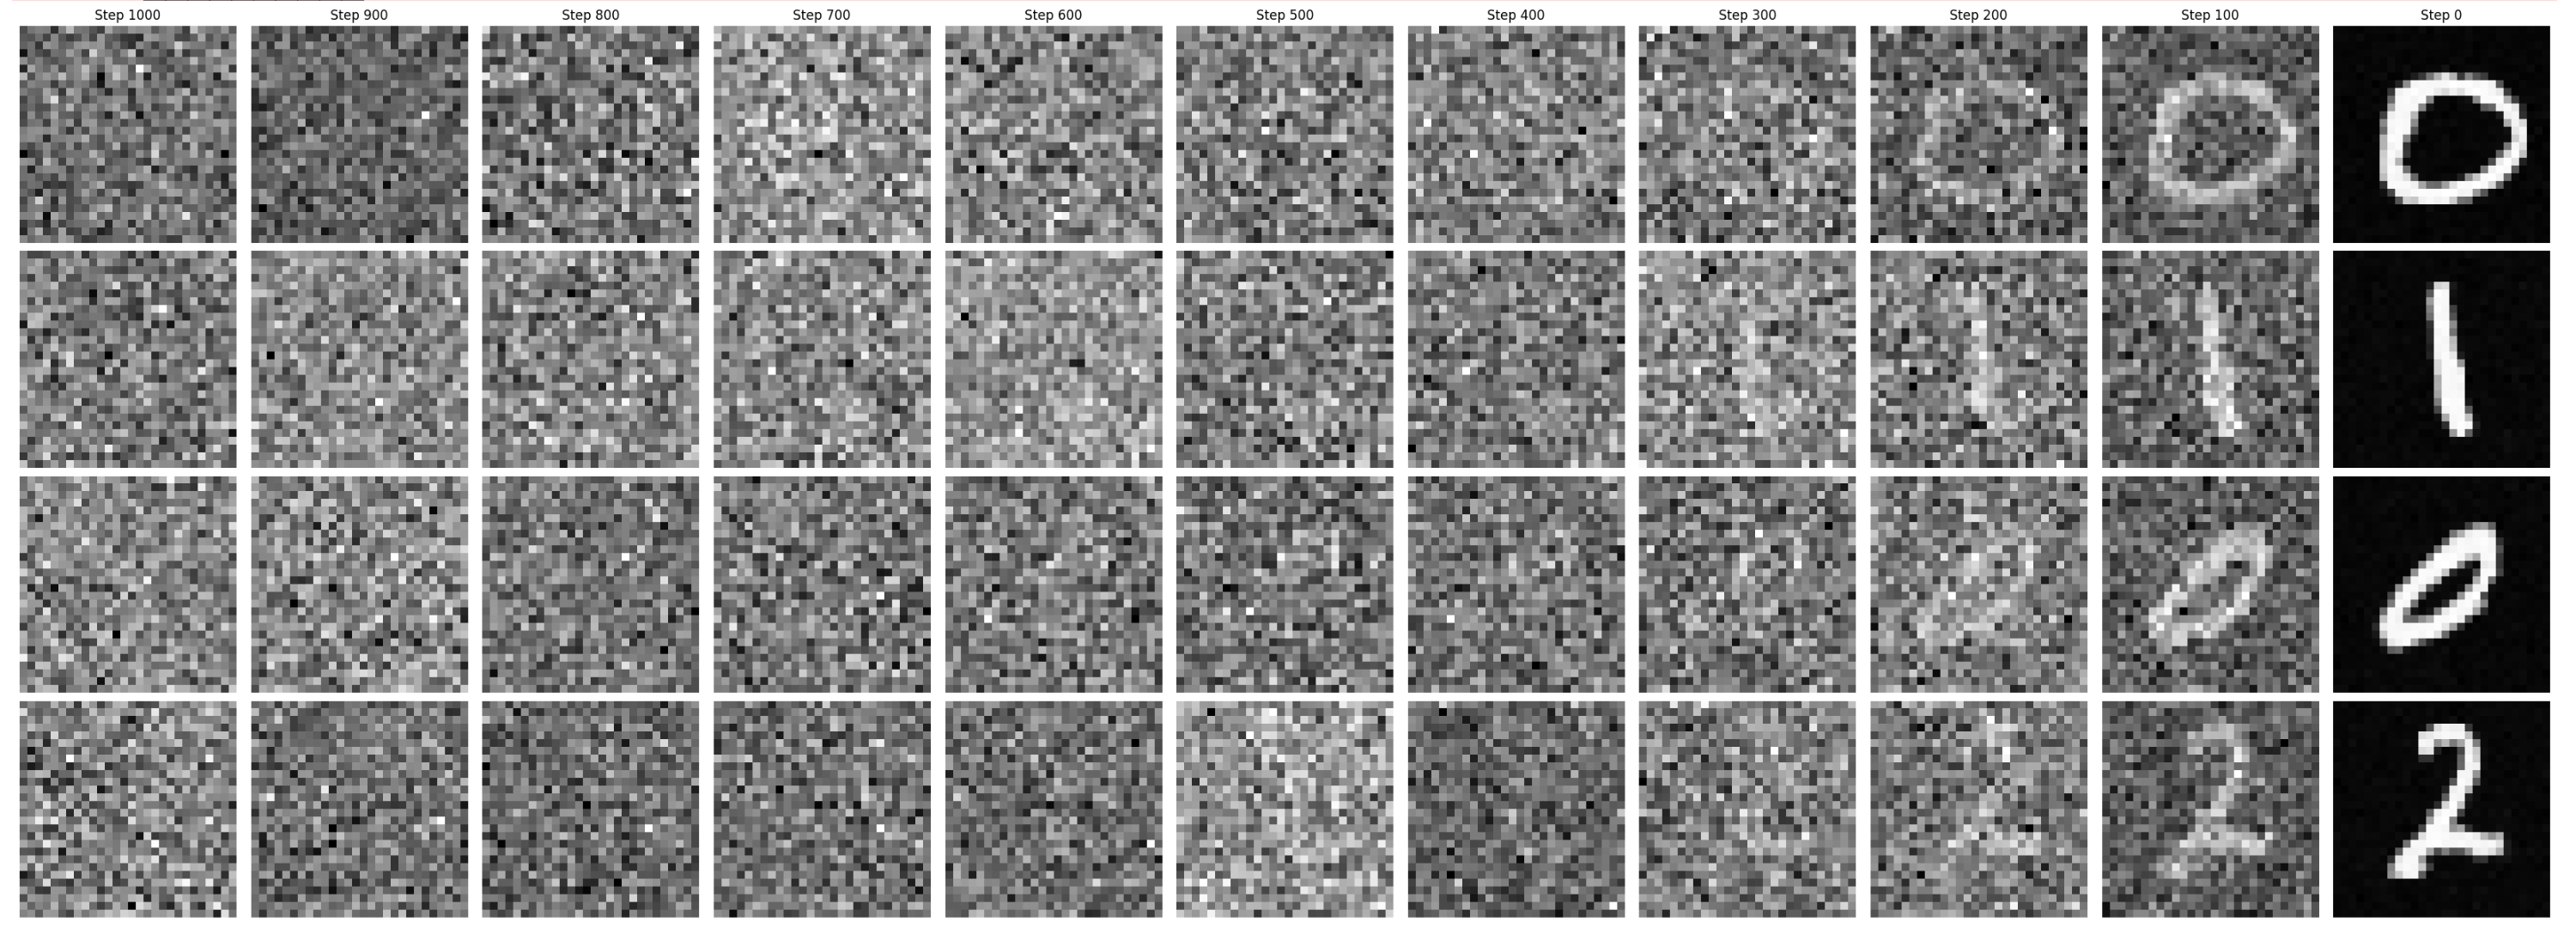

## Part 4: Conditional Generation

In this part, we will use the model we already trained along with a classifier to generate images that are conditioned on a certain class. Specifically, if we are using MNIST we will generate images of the number 5 and if we are using Fashion MNIST we will generate images of sandals (label 5). Note that the training in this section shouldn't take much time as we are using relatively simple datasets, and we are not training a new score model.

For help in this part, we refer you to the variety of open source implementations of this architecture.

1. Train a CNN classifier on your chosen dataset, noising the images according to the SDE to help the model deal with the noisy images that it will receive in generation. The classifier should reach at least 90% accuracy on the test set without noise (and in reality should reach even 98%+). You can choose to either implement $p_t(y|x)$ or just $p(y|x)$ (time can be an input to the CNN if you wish, not necessary for good enough results).
2. Use the score model from part 3 along with the classifier to sample images using classifier guidance. Sample using the same method of sampling that you chose in part 3, replacing the original score with the new "score". Play with the hyperparameter $\gamma$ (at least 3 different positive values) and briefly explain how different values of $\gamma$ influence the generated images. Generate 64 conditional images for each $\gamma$.
3. For the largest $\gamma$ you choose, run the classifier that you trained on the 64 images you generated. You should reach at least 70% accuracy on these images (meaning the classifier guidance should generate a majority of images that look like the correct class).

First, let's train a simple CNN that we can use later in the controllable generation

In [14]:
# a simple CNN
KERNEL_SIZE = 3
STRIDE = 1
PADDING = 1
NUM_CLASSES = 10

class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(

            # convolutions and pooling layers
            nn.Conv2d(1, 32, kernel_size=KERNEL_SIZE, stride=STRIDE, padding=PADDING),
            nn.SiLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=KERNEL_SIZE, stride=STRIDE, padding=PADDING),
            nn.SiLU(),
            nn.MaxPool2d(2),

            # MLP
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 256),
            nn.ReLU(),
            nn.Linear(256, NUM_CLASSES)
        )

    def forward(self, x):
        return self.net(x)

In [15]:
from torchvision import datasets, transforms

# datasets and dataloaders
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x * 2.0 - 1.0)
])

train_dataset = datasets.MNIST("data", train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST("data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

/home/zakhar/miniforge3/envs/cs236207/lib/python3.11/site-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [159]:
classifier_model = CNN().to(device)
optimizer = torch.optim.Adam(classifier_model.parameters(), lr=LR)
loss_fn = nn.CrossEntropyLoss()


def train_classifier(model, train_loader, optimizer, loss_fn, chkpt_path='checkpoints/HW3/clf_mnist', num_epochs=NUM_EPOCHS, epoch_start=0):
    model.train()
    loss_steps = list() 
    for epoch in tqdm(range(num_epochs)):
        loss_accum = 0.
        for x, y in train_loader:
            output = model(x.to(device))
            optimizer.zero_grad()
            loss = loss_fn(output, y.to(device))
            loss_accum += loss.item() 
            loss.backward()
            optimizer.step()
        loss_steps.append(loss_accum)
        if (epoch+1) % 5 == 0:
            print(f"Epoch: {epoch+1}, Loss: {loss_accum}")
            torch.save({'model': classifier_model.state_dict(), 'optim': optimizer.state_dict(), 'epoch': epoch},\
                       f"{chkpt_path}_chkpt{epoch+epoch_start+1}.pth")

  8%|▊         | 5/60 [00:52<09:30, 10.37s/it]

Epoch: 5, Loss: 8.793417122971732


 17%|█▋        | 10/60 [01:43<08:35, 10.31s/it]

Epoch: 10, Loss: 3.0812274257659737


 25%|██▌       | 15/60 [02:36<07:54, 10.55s/it]

...

Epoch: 50, Loss: 0.43919035815195334


 92%|█████████▏| 55/60 [09:22<00:49,  9.94s/it]

Epoch: 55, Loss: 0.951006967860835


100%|██████████| 60/60 [10:11<00:00, 10.20s/it]

Epoch: 60, Loss: 0.5946062550924291


Now, let's evaluate the classifier

In [164]:
def eval_classifier(model, test_loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in test_loader:
            y_pred = model(x.to(device)).argmax(dim=1)
            correct += (y_pred == y.to(device)).sum().item()
            total += y.size(0)

    acc = 100.0 * correct / total
    print(f"Test Accuracy: {acc}")

eval_classifier(classifier_model, test_loader)

Test Accuracy: 99.11


We will make a function similarly to how we have done with the score function (`get_score_model`) to get the $\nabla_x \log p(x | y)$, where $x$ is an image and $y$ is the label that we want to generate. This will allow us to step towrds the wanted class, rather than any high density region in the distribution.

In [44]:
# loading models from a checkpoint
chkpt_classifier = torch.load('checkpoints/HW3/clf_mnist_chkpt60.pth', weights_only=True)
chkpt_noise = torch.load('checkpoints/HW3/sde_model_chkpt60.pth', weights_only=True)

classifier_model = CNN().to(device)
classifier_model.load_state_dict(chkpt_classifier['model'])
noise_model = Unet(
                        sin=True,
                        dim=IMG_SIZE,
                        channels=1,
                        dim_mults=(1, 2, 4)
                    ).to(device)
noise_model.load_state_dict(chkpt_noise['model'])

BETA_0 = 1e-1
BETA_1 = 20
T = 1000

sde = DDPM_SDE(BETA_0, BETA_1, T, device)

In [45]:
def get_cond_score_fn(score_model, classifier_model, class_label, gamma):

    def cond_score_fn(x, t):
        classifier_model.eval()
        score = score_model(x, t)
        with torch.enable_grad():
            x_diff = x.detach().clone().requires_grad_(True)
            logits = classifier_model(x_diff)
            log_p = F.log_softmax(logits, dim=1)[:, class_label].sum()
            grad = torch.autograd.grad(log_p, x_diff)[0]

        return score + gamma * grad

    return cond_score_fn

100%|██████████| 1000/1000 [00:18<00:00, 53.03it/s]


Saving for gamma=1.0


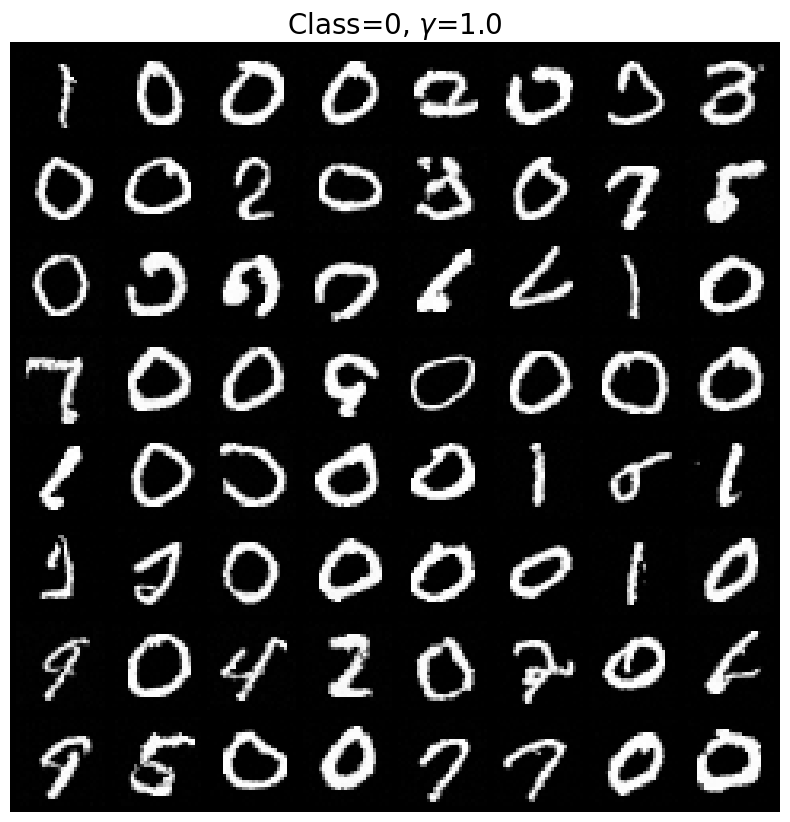

100%|██████████| 1000/1000 [00:18<00:00, 53.09it/s]


Saving for gamma=4.0


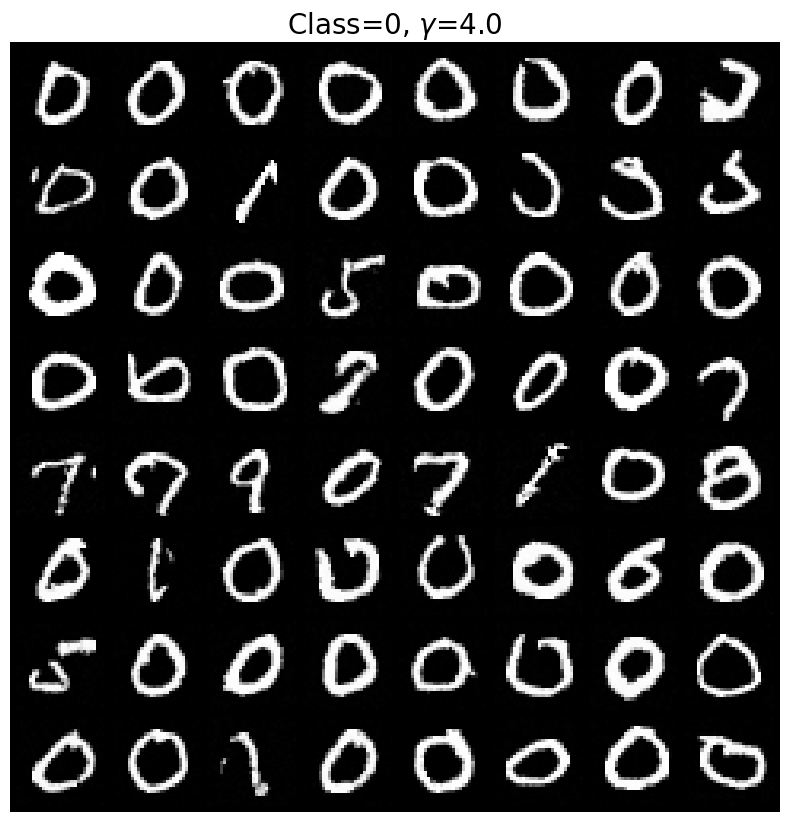

100%|██████████| 1000/1000 [00:18<00:00, 52.88it/s]


Saving for gamma=7.0


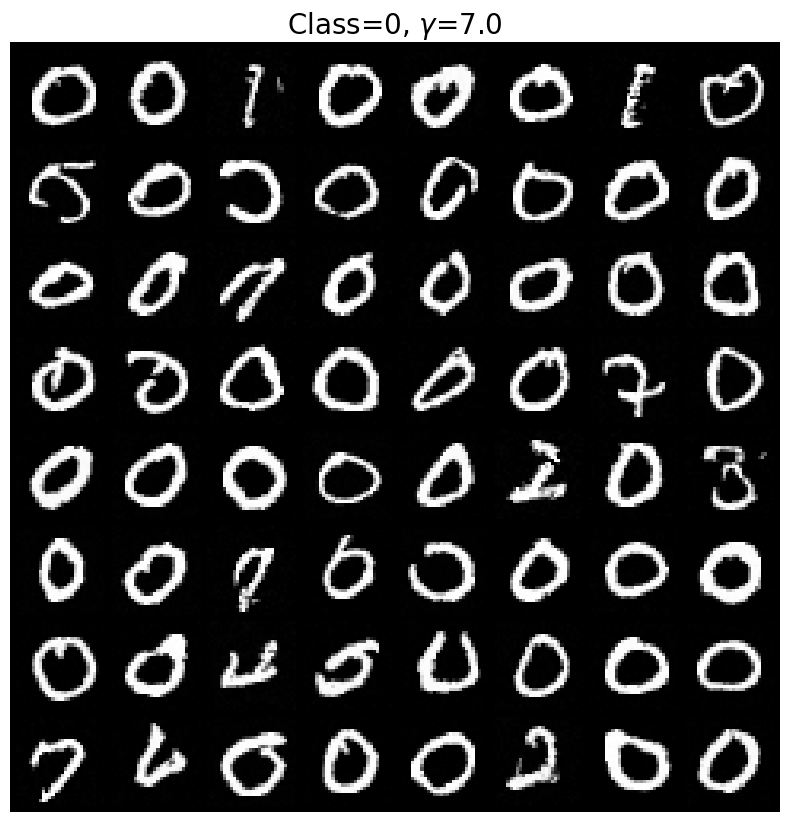

In [62]:
import matplotlib.image as im

score_model = get_score_model(noise_model, sde)
gamma_values = [1., 4., 7.]
shape = (64, 1, 28, 28)
target_class = 0

def guided_sampling(sde, score_model, T, x_0):
    dt = -1.0 / T
    x  = x_0.to(device)
    for i in tqdm(range(T)):
        t = torch.full((x.size(0),), 1.0 - i / T, device=x.device)
        mu_rev, sig_rev = sde.reverse_drift_diffusion(score_model, x, t.to(device))
        noise = torch.zeros_like(x, device=x.device) if (i == T - 1) else torch.randn_like(x, device=x.device)
        x = x + mu_rev * dt + sig_rev[:, None, None, None] * math.sqrt(-dt) * noise
    return x

for i, gamma in enumerate(gamma_values):
    cond_score_fn = get_cond_score_fn(score_model, classifier_model, class_label=target_class, gamma=gamma)
    x_0 = torch.randn(64, 1, 28, 28)
    x_final = guided_sampling(sde, cond_score_fn, T, x_0)
    saved = x_final.clone()
    saved = (saved + 1) * 0.5
    saved = saved.clamp(0, 1)
    print(f"Saving for gamma={gamma}")
    save_image(saved, f'images/HW3/part4_imgs_gamma{i}.png')  

    img = im.imread(f'images/HW3/part4_imgs_gamma{i}.png')
    plt.figure(figsize=(10, 10))
    plt.imshow(img, cmap='gray')
    plt.title(f"Class={target_class}, $\gamma$={gamma}", fontsize=20)
    plt.axis("off")
    plt.show()

Now, let's run the classifier on the last generated batch of images (for $\gamma$=7)

In [64]:
y_pred = classifier_model(x_final.to(device)).argmax(dim=1)
correct = 0.
total = len(x_final)
correct += ((y_pred == 0).to(device)).sum().item()
acc = 100.0 * correct / total
print(f"Accuracy on the controlled generation: {acc}")

Accuracy on the controlled generation: 82.8125


We see that visually, most of the images generated by the "controllable" score conditioned on the label indeed look like they are of that label. This is also supported by verifying the model's "accuracy" if we assume that all these images come from the target label. The classifier model (that has a 99.1% accuracy on the test set) predicts that 82.81% of the generated batch of images come from the wanted target label (for $\gamma=4.0$).

Not all images need to be perfect, for example the following output is acceptable for $\gamma=1$.

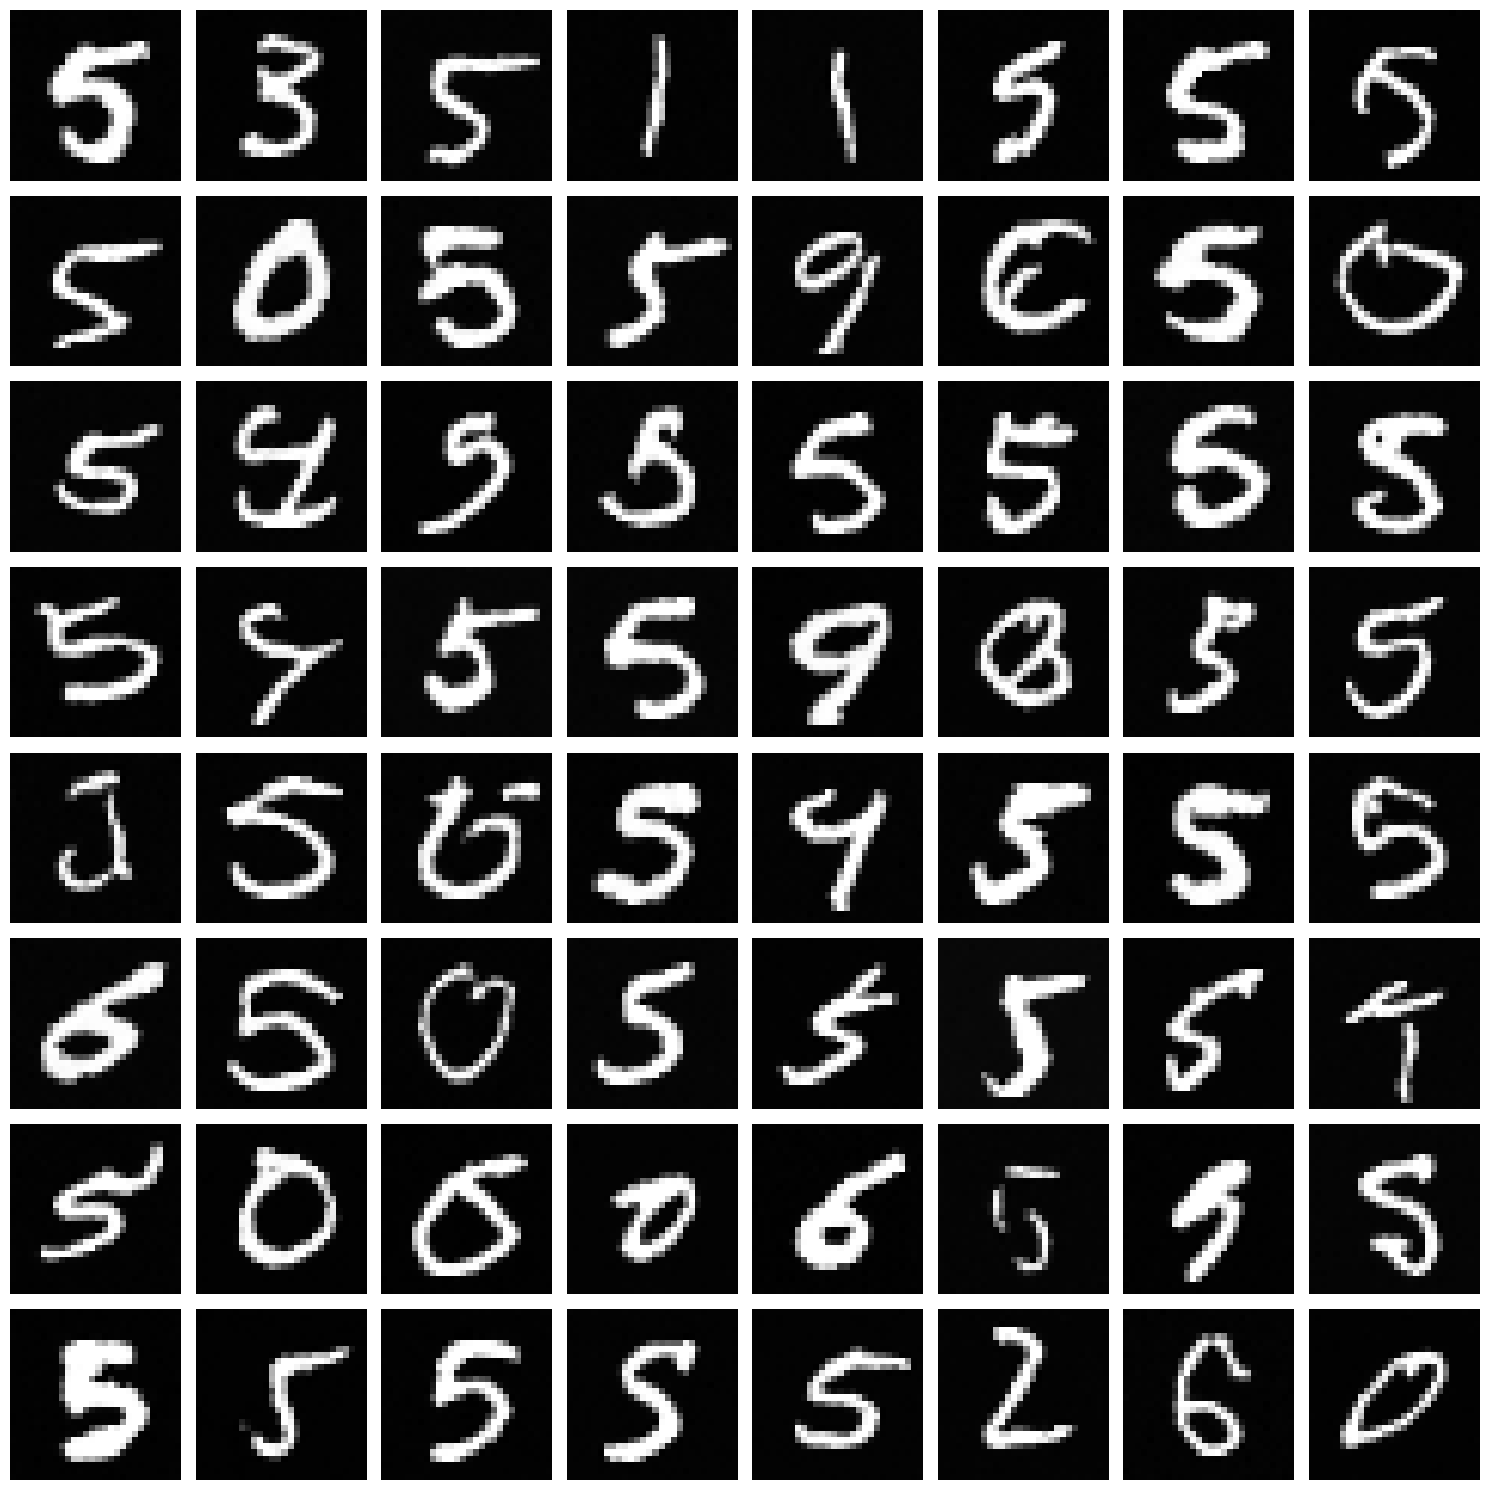